In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [63]:
df = pd.read_csv('pop_data/source-data-unhcr-pdf-reports.csv')

df.head()

,date,days,Niger,Burkina,Maurit,Togo,Guinea,Total,Internally Displaced
0,08-03-2012,0,16134,22639,34156,20,45,69350,81463
1,19-03-2012,11,18965,22974,39490,20,45,81494,93439
2,30-03-2012,22,19927,22974,46008,20,45,88974,93439
3,24-04-2012,47,36688,46354,60998,20,45,144105,132724
4,15-05-2012,68,38242,56817,61287,20,44,156410,146900


In [64]:

date = pd.to_datetime(df['date'],format = '%d-%m-%Y')
nig = np.array(df['Niger'])
bf = np.array(df['Burkina']+df['Togo'])
mau = np.array(df['Maurit'])
gui = np.array(df['Guinea'])
ref = np.array(df['Total'])
idp = np.array(df['Internally Displaced'])
oth = ref - nig - bf - mau - gui




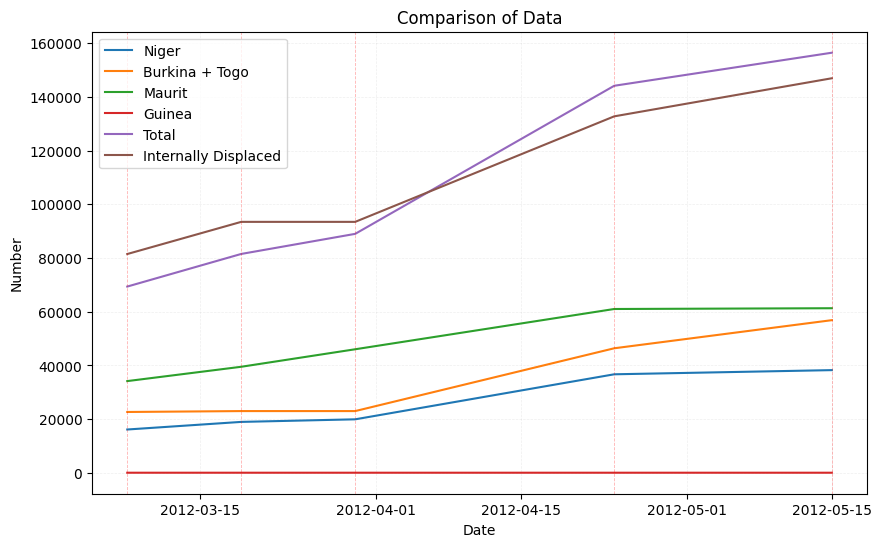

In [65]:
plt.figure(figsize=(10, 6))

plt.plot(date, nig, label='Niger')
plt.plot(date, bf, label='Burkina + Togo')
plt.plot(date, mau, label='Maurit')
plt.plot(date, gui, label='Guinea')
plt.plot(date, ref, label='Total')
plt.plot(date, idp, label='Internally Displaced')

# --- VERTICAL DASHED LINES AT DATA POINTS ---
for d in date:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.3)

plt.xlabel('Date')
plt.ylabel('Number')
plt.title('Comparison of Data')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.2)

plt.show()

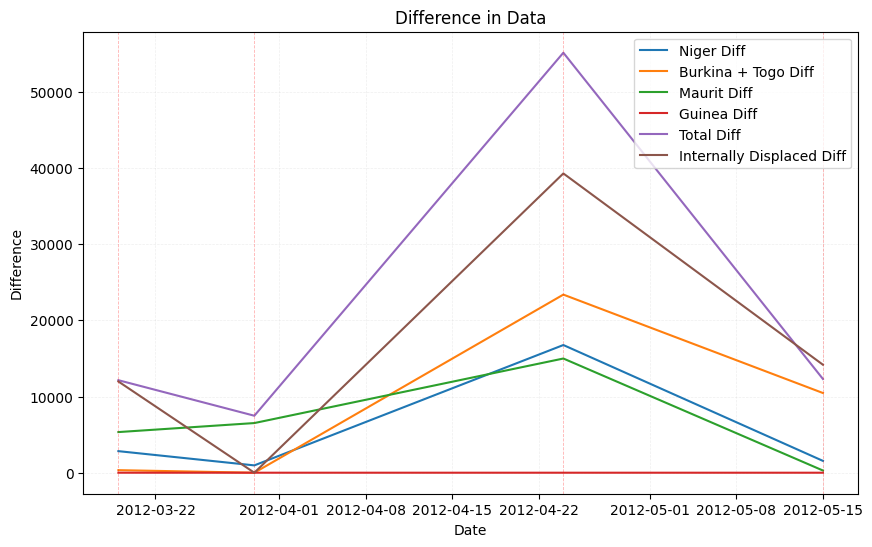

In [66]:
date = pd.to_datetime(df['date'], format='%d-%m-%Y')
nig_diff = np.diff(np.array(df['Niger']))
bf_diff = np.diff(np.array(df['Burkina'] + df['Togo']))
mau_diff = np.diff(np.array(df['Maurit']))
gui_diff = np.diff(np.array(df['Guinea']))
ref_diff = np.diff(np.array(df['Total']))
idp_diff = np.diff(np.array(df['Internally Displaced']))
unhcr_dates = pd.to_datetime(df['date'], format='%d-%m-%Y').dropna().unique()

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(date[1:], nig_diff, label='Niger Diff')
plt.plot(date[1:], bf_diff, label='Burkina + Togo Diff')
plt.plot(date[1:], mau_diff, label='Maurit Diff')
plt.plot(date[1:], gui_diff, label='Guinea Diff')
plt.plot(date[1:], ref_diff, label='Total Diff')
plt.plot(date[1:], idp_diff, label='Internally Displaced Diff')

# --- VERTICAL DASHED LINES AT DATA POINTS ---
for d in date[1:]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.3)

plt.xlabel('Date')
plt.ylabel('Difference')
plt.title('Difference in Data')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.2)

plt.show()

In [67]:
date_range = pd.date_range(start='2012-01-01', end='2013-01-01')

def prepare_data(df, date_col, value_col, date_range):
    df[date_col] = pd.to_datetime(df[date_col], format='%Y-%m-%d', errors='coerce')
    df.set_index(date_col, inplace=True)

    df['is_real'] = True

    df = df.reindex(date_range)
    df['is_real'] = df['is_real'].fillna(False)  # missing dates = interpolated
    df[value_col] = df[value_col].interpolate(method='time')

    df[value_col] = df[value_col].ffill().bfill()

    # FIX: Resets the index to 0, 1, 2... so your camp[i] loop works perfectly
    return df.reset_index(drop=True)

#nig

tabareybarey = pd.read_csv('pop_data/nig-tabareybarey.csv')
tabareybarey = prepare_data(tabareybarey, '#DateTime','Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)', date_range)

niamey = pd.read_csv('pop_data/nig-niamey.csv')
niamey = prepare_data(niamey, '#DateTime','Nombre estimé de réfugiés maliens par période', date_range)

mangaize = pd.read_csv('pop_data/nig-mangaize.csv')
mangaize = prepare_data(mangaize, '#DateTime','Nombre estimé de réfugiés maliens par période', date_range)

intikane = pd.read_csv('pop_data/nig-intikane.csv')
intikane = prepare_data(intikane, 'DateTime','Nombre estimé de réfugiés maliens par période', date_range)

abala = pd.read_csv('pop_data/nig-abala.csv')
abala = prepare_data(abala, '#DateTime','Nombre estimé de réfugiés maliens par période', date_range)

#mau

mbera = pd.read_csv('pop_data/mau-mbera.csv')
mbera = prepare_data(mbera, 'DateTime','Réfugiés maliens', date_range)

fassala = pd.read_csv('pop_data/mau-fassala.csv')
fassala = prepare_data(fassala, 'DateTime','Réfugiés maliens', date_range)

#bf

ouagadougou = pd.read_csv('pop_data/bf-ouagadougou.csv')
ouagadougou = prepare_data(ouagadougou, '#DateTime','Nombre estimé de réfugiés maliens par période', date_range)

mentao = pd.read_csv('pop_data/bf-mentao.csv')
mentao = prepare_data(mentao, '#DateTime','Nombre estimé de réfugiés maliens par période (border opens on 21st of March)', date_range)

goudoubo = pd.read_csv('pop_data/bf-goudoubo.csv')
goudoubo = prepare_data(goudoubo, '#DateTime','Nombre estimé de réfugiés maliens par période', date_range)

bobo = pd.read_csv('pop_data/bf-bobo.csv')
bobo = prepare_data(bobo, '#DateTime','Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)', date_range)


camps = [bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'],
         goudoubo['Nombre estimé de réfugiés maliens par période'],
         mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'],
         ouagadougou['Nombre estimé de réfugiés maliens par période'],
         fassala['Réfugiés maliens'],
         mbera['Réfugiés maliens'],
         abala['Nombre estimé de réfugiés maliens par période'],
         mangaize['Nombre estimé de réfugiés maliens par période'],
         niamey['Nombre estimé de réfugiés maliens par période'],
         tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)']]

total_refugees_emp = np.zeros(len(camps[0]))
for i in range(len(camps[0])):
    for camp in camps:
        total_refugees_emp[i]+=camp[i]

print(total_refugees_emp)

[ 20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20075.          20075.          20075.          20075.
  20806.63797777  21538.27595554  22269.91393332  23001.55191109
  23733.18988886  24464.82786663  25196.4658444   25794.91334598
  26393.3608475

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/1243831336.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_real'] = df['is_real'].fillna(False)  # missing dates = interpolated
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/1243831336.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_real'] = df['is_real'].fillna(False)  # missing dates = interpolated
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/1243831336.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bf

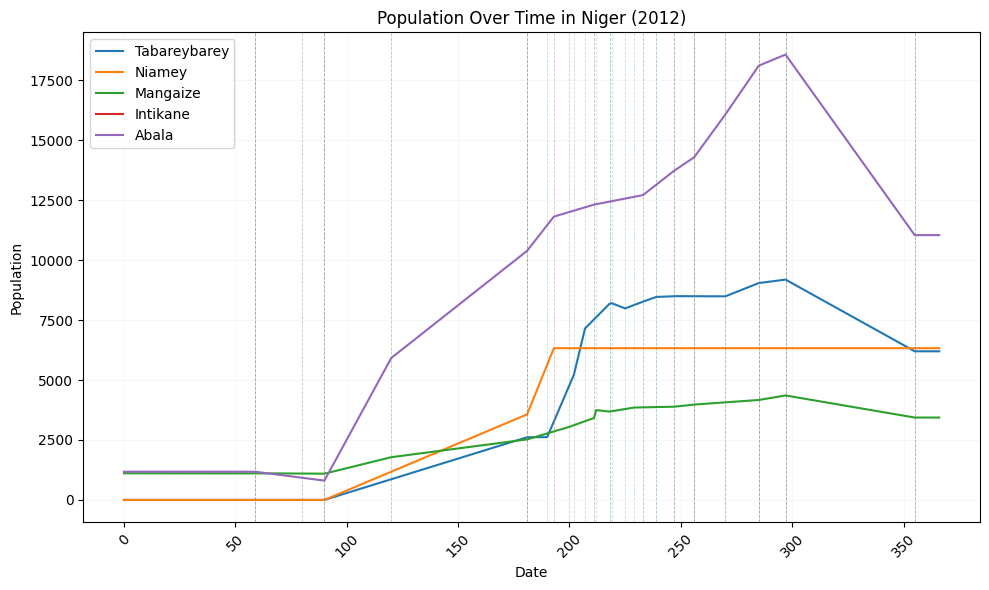

In [68]:
plt.figure(figsize=(10, 6))

# --- Plot lines and store them ---
line1, = plt.plot(tabareybarey.index, tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'], label='Tabareybarey')
line2, = plt.plot(niamey.index, niamey['Nombre estimé de réfugiés maliens par période'], label='Niamey')
line3, = plt.plot(mangaize.index, mangaize['Nombre estimé de réfugiés maliens par période'], label='Mangaize')
line4, = plt.plot(intikane.index, intikane['Nombre estimé de réfugiés maliens par période'], label='Intikane')
line5, = plt.plot(abala.index, abala['Nombre estimé de réfugiés maliens par période'], label='Abala')

# --- Vertical lines per dataset (matching colours) ---
for d in tabareybarey.index[tabareybarey['is_real']]:
    plt.axvline(x=d, color=line1.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in niamey.index[niamey['is_real']]:
    plt.axvline(x=d, color=line2.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in mangaize.index[mangaize['is_real']]:
    plt.axvline(x=d, color=line3.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in intikane.index[intikane['is_real']]:
    plt.axvline(x=d, color=line4.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in abala.index[abala['is_real']]:
    plt.axvline(x=d, color=line5.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

plt.title('Population Over Time in Niger (2012)')
plt.xlabel('Date')
plt.ylabel('Population')

plt.grid(True, linewidth=0.5, alpha=0.15)

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

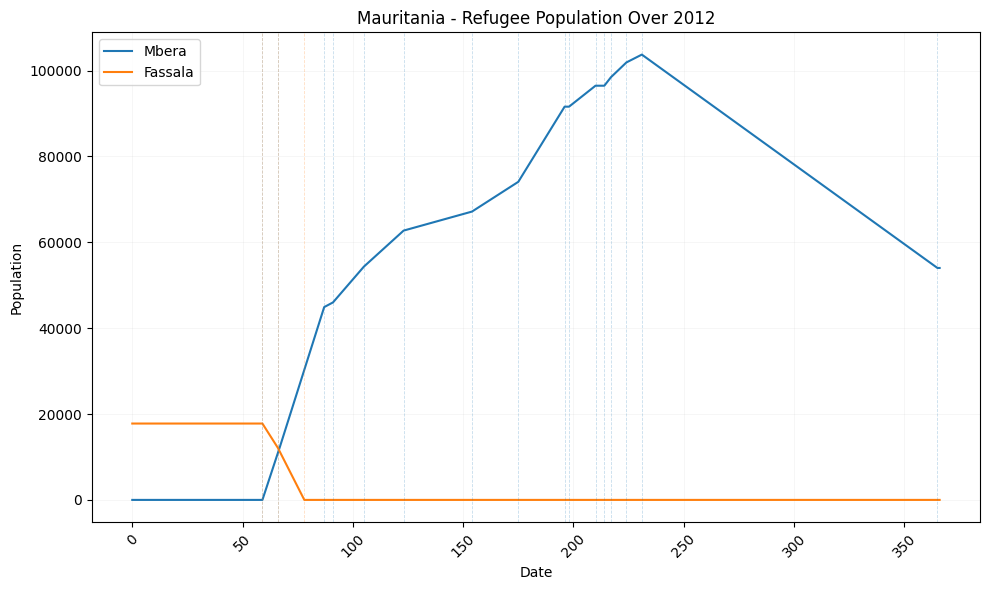

In [69]:
plt.figure(figsize=(10, 6))

# Plot + capture lines
line1, = plt.plot(mbera.index, mbera['Réfugiés maliens'], label='Mbera')
line2, = plt.plot(fassala.index, fassala['Réfugiés maliens'], label='Fassala')

# Vertical lines (matching colours)
for d in mbera.index[mbera['is_real']]:
    plt.axvline(x=d, color=line1.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in fassala.index[fassala['is_real']]:
    plt.axvline(x=d, color=line2.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

plt.title('Mauritania - Refugee Population Over 2012')
plt.xlabel('Date')
plt.ylabel('Population')

plt.grid(True, linewidth=0.5, alpha=0.15)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

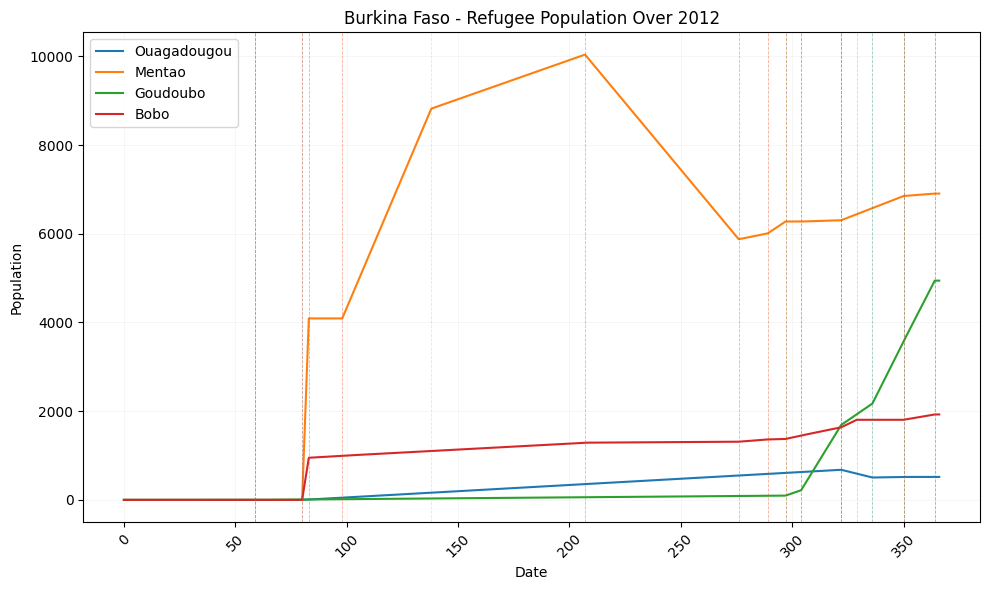

In [70]:
plt.figure(figsize=(10, 6))

# Plot + capture lines
line1, = plt.plot(ouagadougou.index, ouagadougou['Nombre estimé de réfugiés maliens par période'], label='Ouagadougou')
line2, = plt.plot(mentao.index, mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'], label='Mentao')
line3, = plt.plot(goudoubo.index, goudoubo['Nombre estimé de réfugiés maliens par période'], label='Goudoubo')
line4, = plt.plot(bobo.index, bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'], label='Bobo')

# Vertical lines (matching colours)
for d in ouagadougou.index[ouagadougou['is_real']]:
    plt.axvline(x=d, color=line1.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in mentao.index[mentao['is_real']]:
    plt.axvline(x=d, color=line2.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in goudoubo.index[goudoubo['is_real']]:
    plt.axvline(x=d, color=line3.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

for d in bobo.index[bobo['is_real']]:
    plt.axvline(x=d, color=line4.get_color(), linestyle='--', linewidth=0.6, alpha=0.25)

plt.title('Burkina Faso - Refugee Population Over 2012')
plt.xlabel('Date')
plt.ylabel('Population')

plt.grid(True, linewidth=0.5, alpha=0.15)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# MAIN RUN
sim = pd.read_csv("clean_run/Camp_splits.csv")


date_sim = pd.to_datetime(sim['Date'])
bobo_sim=sim['Bobo']
goudoubo_sim=sim['Goudoubo']
mentao_sim=sim['Mentao']
ouagadougou_sim=sim['Ouagadougou']
fassala_sim=sim['Fassala']
mbera_sim=sim['Mbera']
abala_sim=sim['Abala']
mangaize_sim=sim['Mangaize']
niamey_sim=sim['Niamey']
tabareybarey_sim=sim['Tabareybarey']



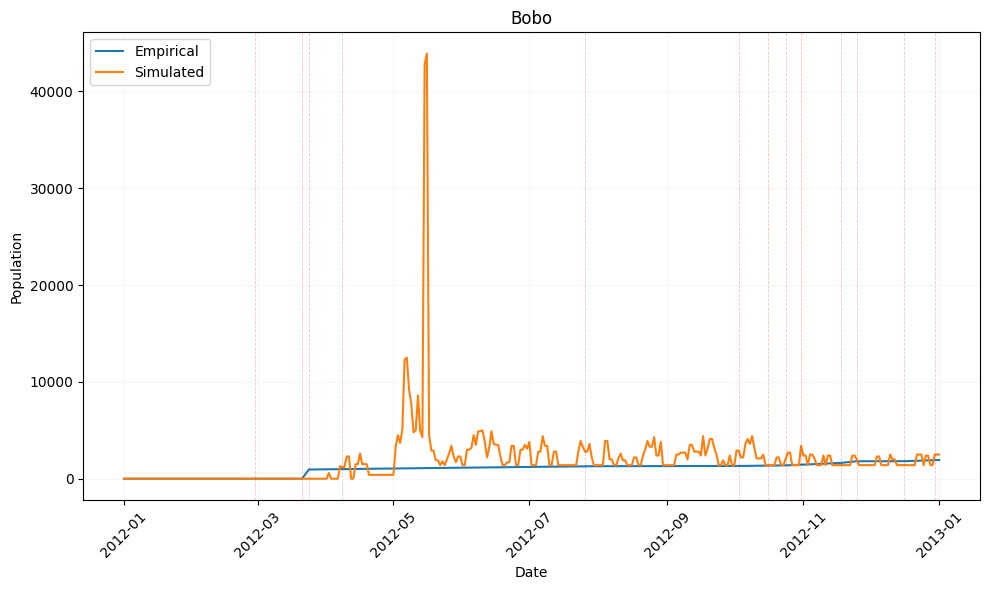

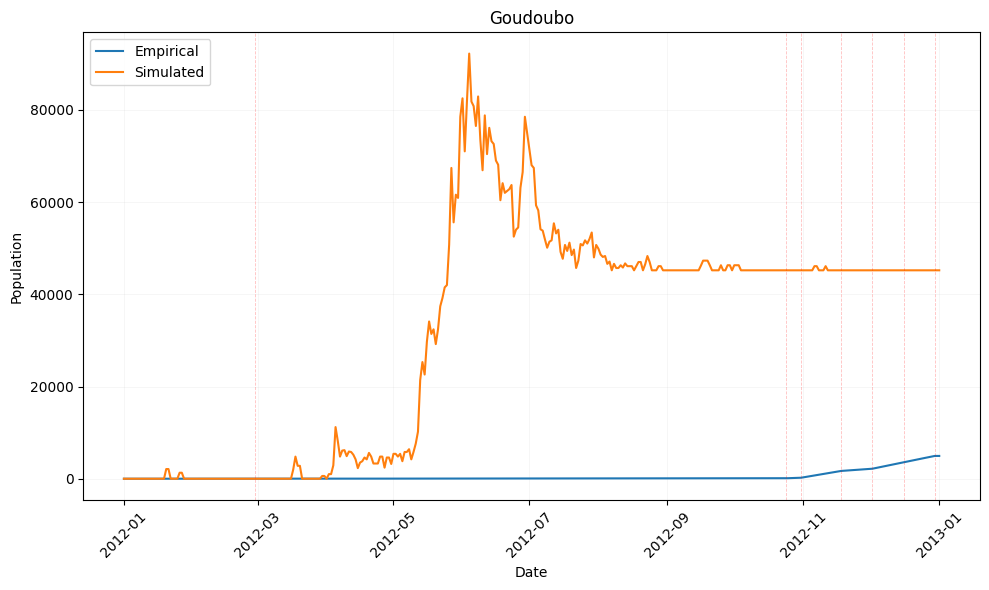

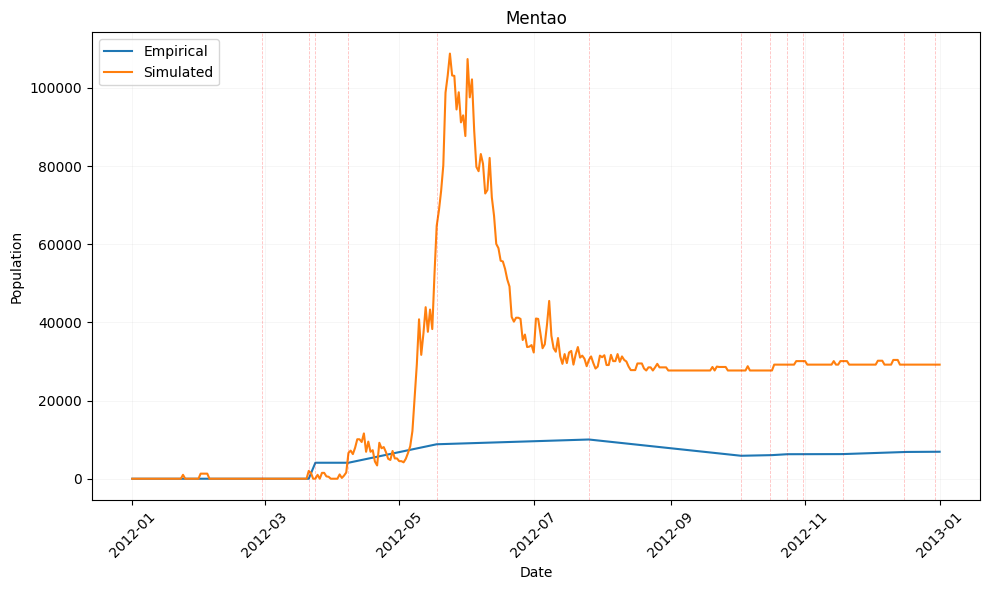

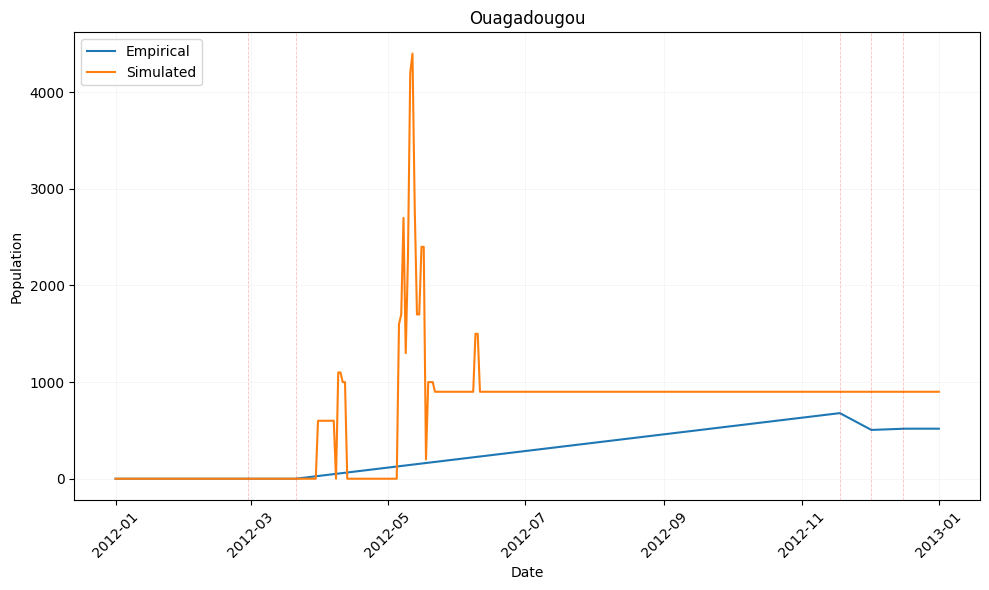

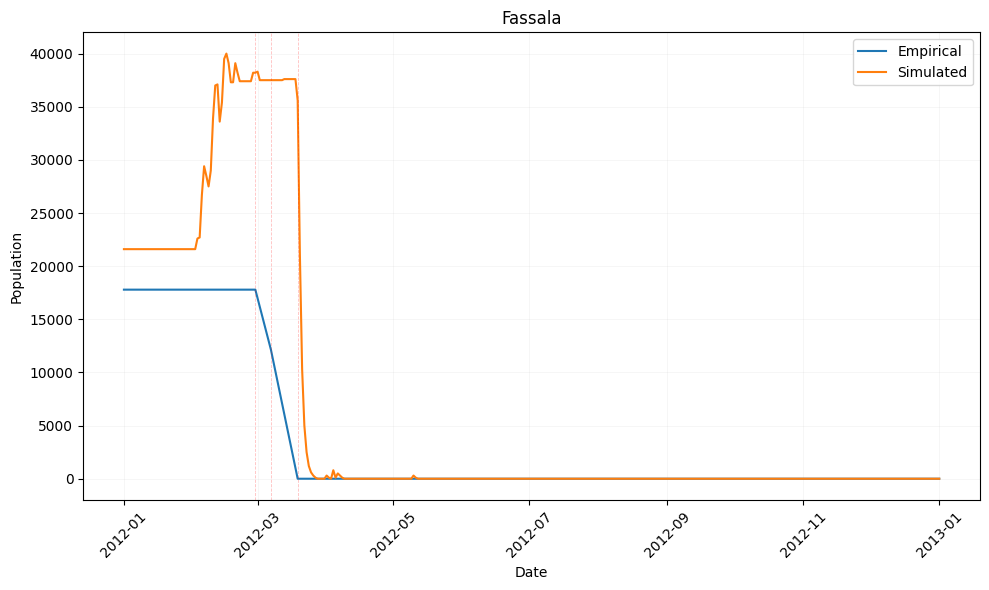

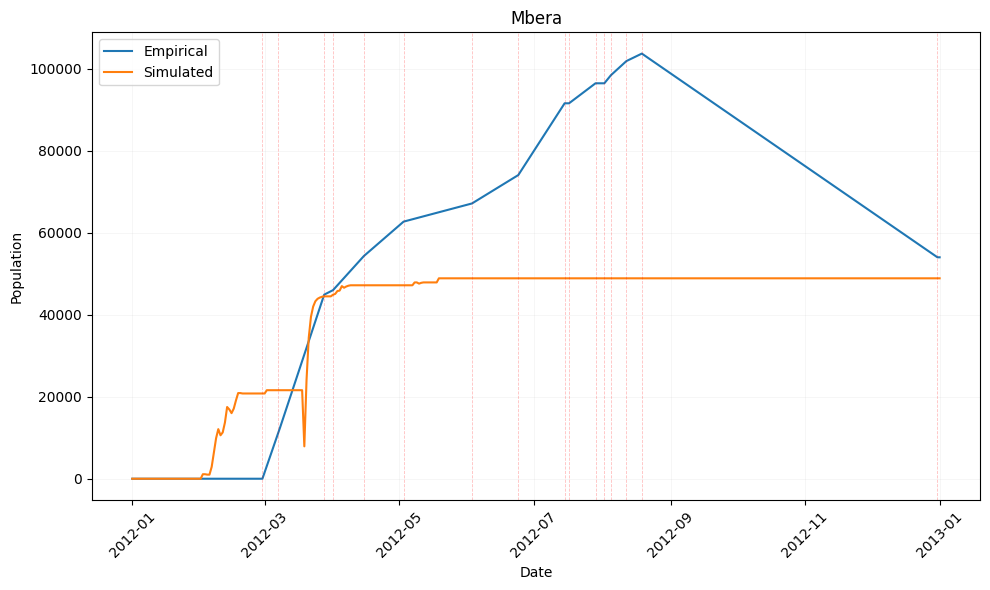

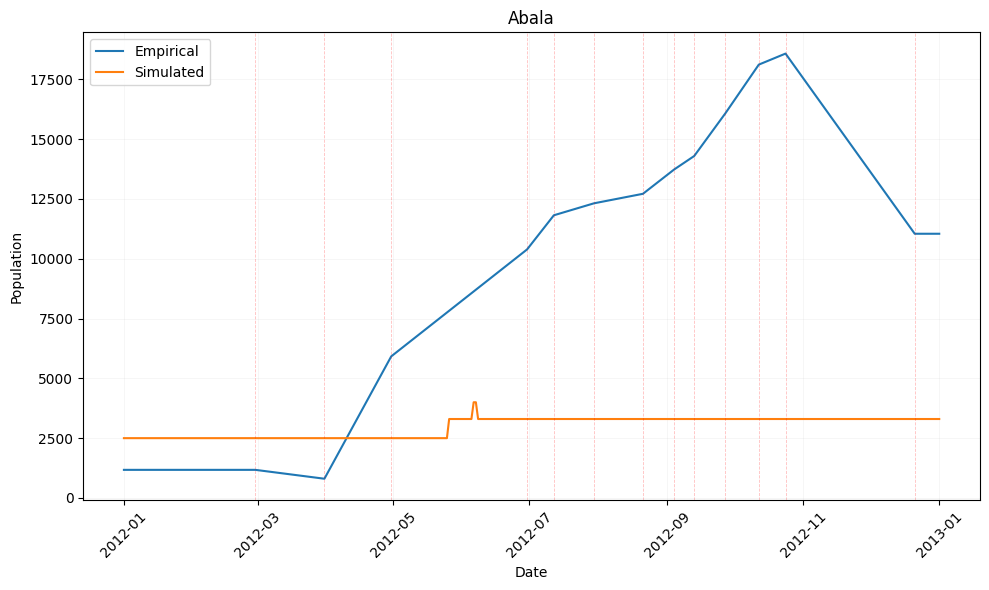

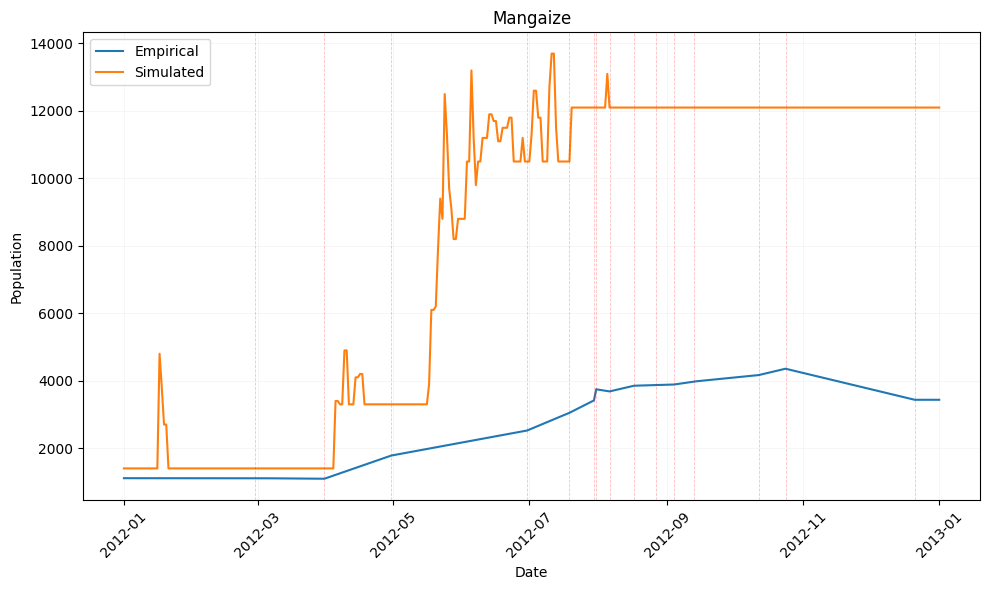

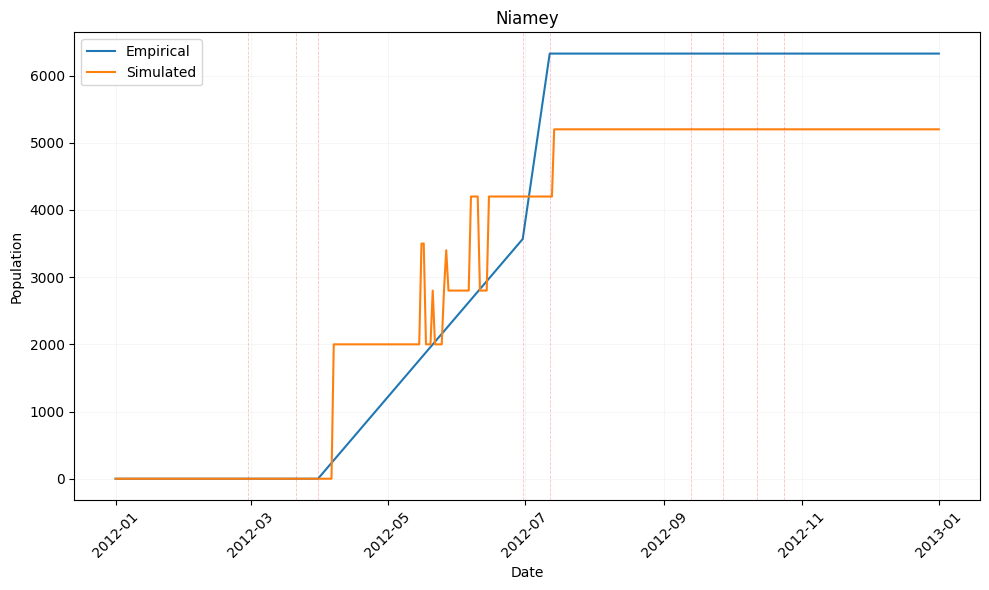

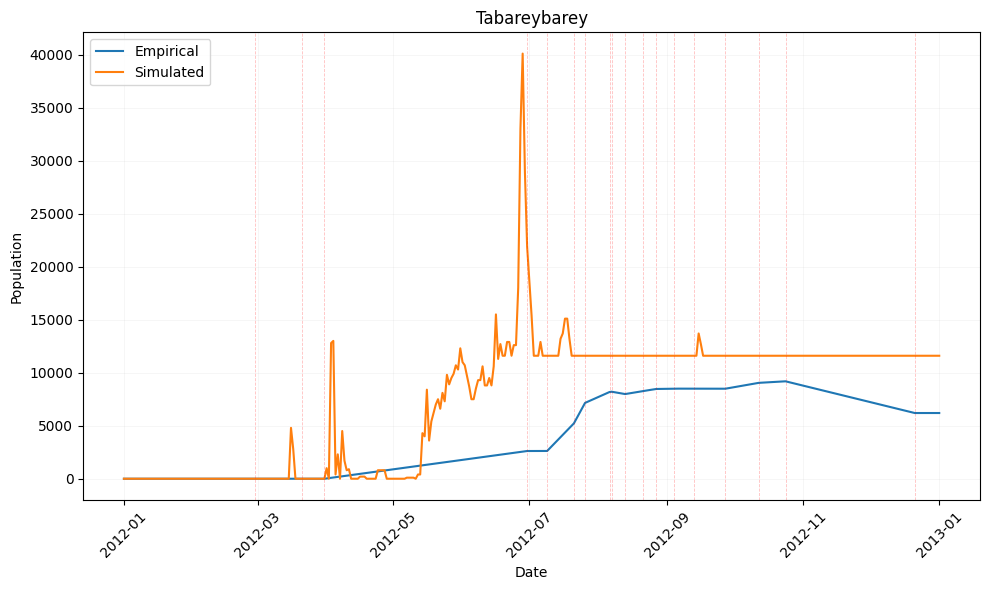

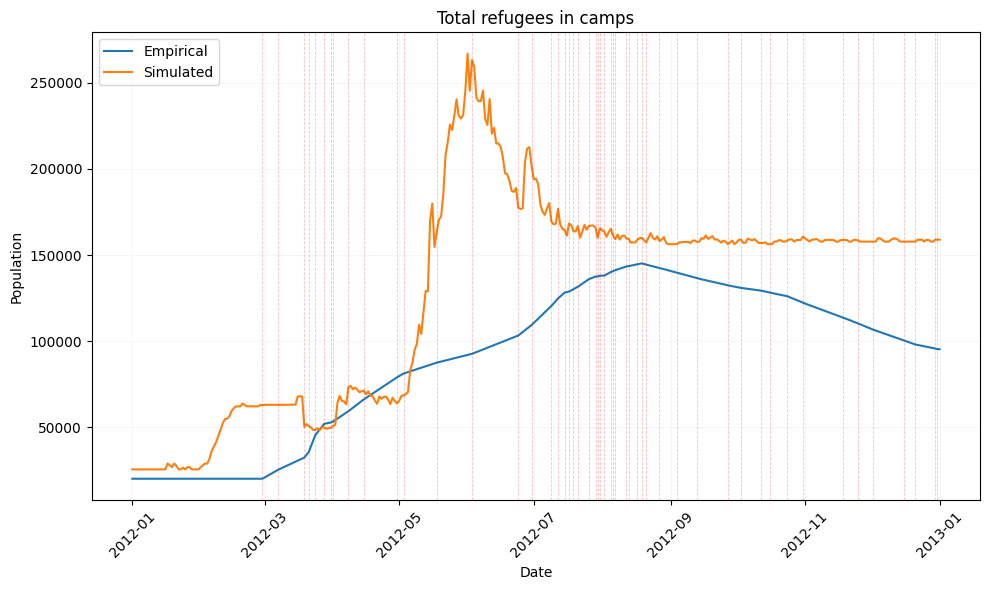

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Function to apply moving average smoothing
def moving_average(series, window_size):
    return series.rolling(window=window_size, min_periods=1).mean()

# Example window size
window_size = 5

# Example of Gaussian smoothing function
def gaussian_smoothing(series, sigma):
    return gaussian_filter1d(series, sigma=sigma)

# Example sigma for Gaussian smoothing
sigma = 2

# Smooth the empirical and simulated data for each dataset

# Bobo
bobo_smoothed = bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)']
bobo_sim_smoothed = moving_average(pd.Series(bobo_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, bobo_smoothed, label='Empirical')
plt.plot(date_sim, bobo_sim, label='Simulated')
for d in date_sim[bobo['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Bobo')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Goudoubo
goudoubo_smoothed = goudoubo['Nombre estimé de réfugiés maliens par période']
goudoubo_sim_smoothed = moving_average(pd.Series(goudoubo_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, goudoubo_smoothed, label='Empirical')
plt.plot(date_sim, goudoubo_sim, label='Simulated')
for d in date_sim[goudoubo['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Goudoubo')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mentao
mentao_smoothed = mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)']
mentao_sim_smoothed = moving_average(pd.Series(mentao_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, mentao_smoothed, label='Empirical')
plt.plot(date_sim, mentao_sim, label='Simulated')
for d in date_sim[mentao['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mentao')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ouagadougou
ouagadougou_smoothed = ouagadougou['Nombre estimé de réfugiés maliens par période']
ouagadougou_sim_smoothed = moving_average(pd.Series(ouagadougou_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, ouagadougou_smoothed, label='Empirical')
plt.plot(date_sim, ouagadougou_sim, label='Simulated')
for d in date_sim[ouagadougou['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Ouagadougou')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Fassala
fassala_smoothed = fassala['Réfugiés maliens']
fassala_sim_smoothed = moving_average(pd.Series(fassala_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, fassala_smoothed, label='Empirical')
plt.plot(date_sim, fassala_sim, label='Simulated')
for d in date_sim[fassala['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Fassala')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mbera
mbera_smoothed = mbera['Réfugiés maliens']
mbera_sim_smoothed = moving_average(pd.Series(mbera_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, mbera_smoothed, label='Empirical')
plt.plot(date_sim, mbera_sim, label='Simulated')
for d in date_sim[mbera['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mbera')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Abala
abala_smoothed = abala['Nombre estimé de réfugiés maliens par période']
abala_sim_smoothed = moving_average(pd.Series(abala_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, abala_smoothed, label='Empirical')
plt.plot(date_sim, abala_sim, label='Simulated')
for d in date_sim[abala['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Abala')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Mangaize
mangaize_smoothed = mangaize['Nombre estimé de réfugiés maliens par période']
mangaize_sim_smoothed = moving_average(pd.Series(mangaize_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, mangaize_smoothed, label='Empirical')
plt.plot(date_sim, mangaize_sim, label='Simulated')
for d in date_sim[mangaize['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mangaize')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Niamey
niamey_smoothed = niamey['Nombre estimé de réfugiés maliens par période']
niamey_sim_smoothed = moving_average(pd.Series(niamey_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, niamey_smoothed, label='Empirical')
plt.plot(date_sim, niamey_sim, label='Simulated')
for d in date_sim[niamey['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Niamey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tabareybarey
tabareybarey_smoothed = tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)']
tabareybarey_sim_smoothed = moving_average(pd.Series(tabareybarey_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, tabareybarey_smoothed, label='Empirical')
plt.plot(date_sim, tabareybarey_sim, label='Simulated')
for d in date_sim[tabareybarey['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Tabareybarey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

camps = [bobo_sim,goudoubo_sim,mentao_sim,ouagadougou_sim,fassala_sim,mbera_sim,abala_sim,mangaize_sim,niamey_sim,tabareybarey_sim]

total_refugees_sim=[0]*len(camps[0])

# Sum the refugee counts for each date across all camps
for i in range(len(camps[0])):
    for camp in camps:
        total_refugees_sim[i]+=camp[i]

plt.figure(figsize=(10, 6))
plt.plot(date_sim, total_refugees_emp, label='Empirical')
plt.plot(date_sim, total_refugees_sim, label='Simulated')
is_real_total = (
    bobo['is_real'] |
    goudoubo['is_real'] |
    mentao['is_real'] |
    ouagadougou['is_real'] |
    fassala['is_real'] |
    mbera['is_real'] |
    abala['is_real'] |
    mangaize['is_real'] |
    niamey['is_real'] |
    tabareybarey['is_real']
)

for d in date_sim[is_real_total]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Total refugees in camps')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()   

bobo_upscaled=[]
goudoubo_upscaled=[]
mentao_upscaled=[]
ouagadougou_upscaled=[]
fassala_upscaled=[]
mbera_upscaled=[]
abala_upscaled=[]
mangaize_upscaled=[]
niamey_upscaled=[]
tabareybarey_upscaled=[]



for i in range(len(total_refugees_emp)): 
    if total_refugees_sim[i] == 0: 
        upscale = 0 
    else: 
        upscale = total_refugees_emp[i] / total_refugees_sim[i] 
    
    bobo_upscaled.append(bobo_sim[i] * upscale) 
    goudoubo_upscaled.append(goudoubo_sim[i] * upscale) 
    mentao_upscaled.append(mentao_sim[i] * upscale) 
    ouagadougou_upscaled.append(ouagadougou_sim[i] * upscale) 
    fassala_upscaled.append(fassala_sim[i] * upscale) 
    mbera_upscaled.append(mbera_sim[i] * upscale) 
    abala_upscaled.append(abala_sim[i] * upscale) 
    mangaize_upscaled.append(mangaize_sim[i] * upscale) 
    niamey_upscaled.append(niamey_sim[i] * upscale) 
    tabareybarey_upscaled.append(tabareybarey_sim[i] * upscale)

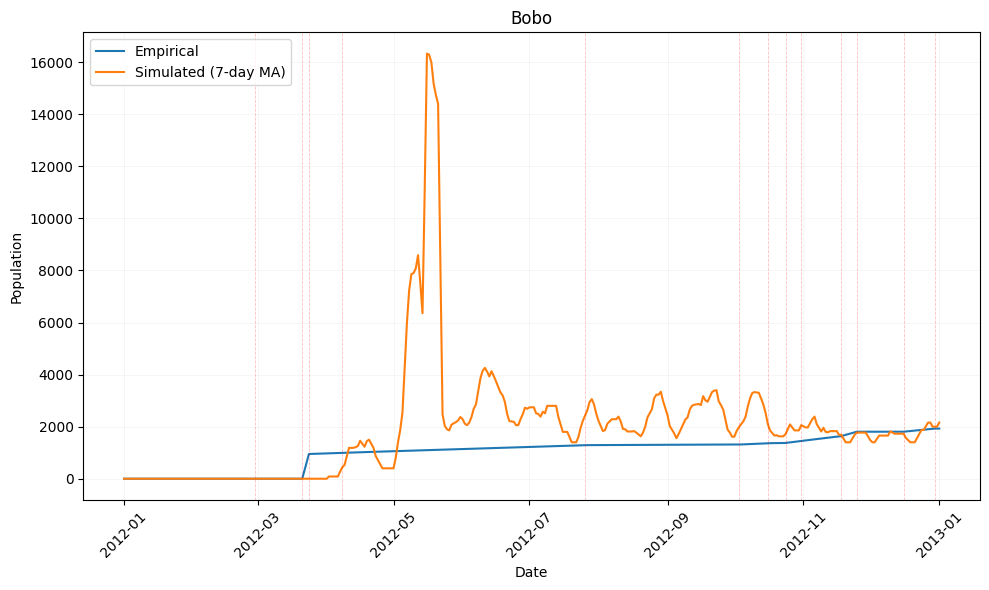

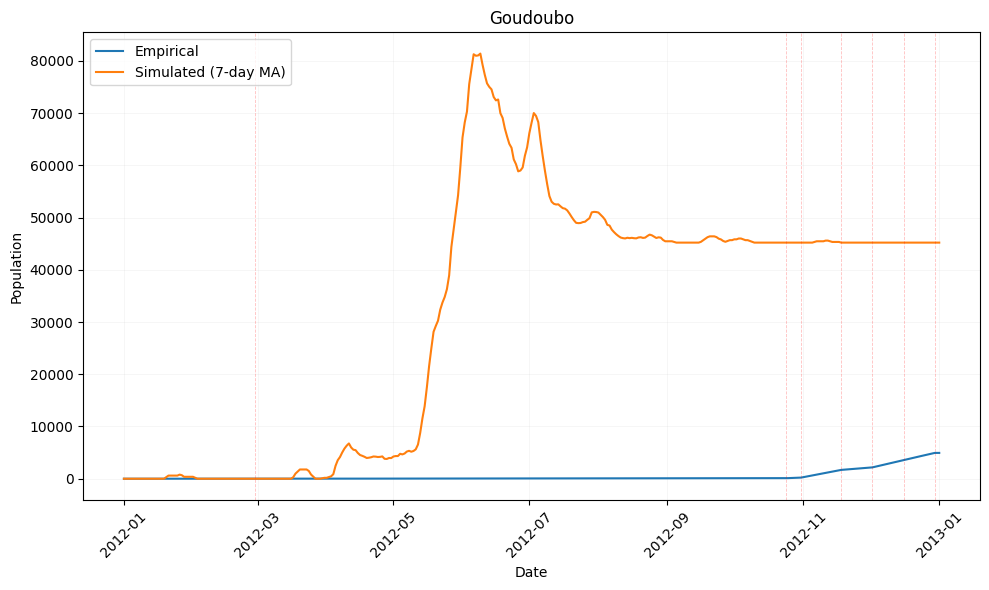

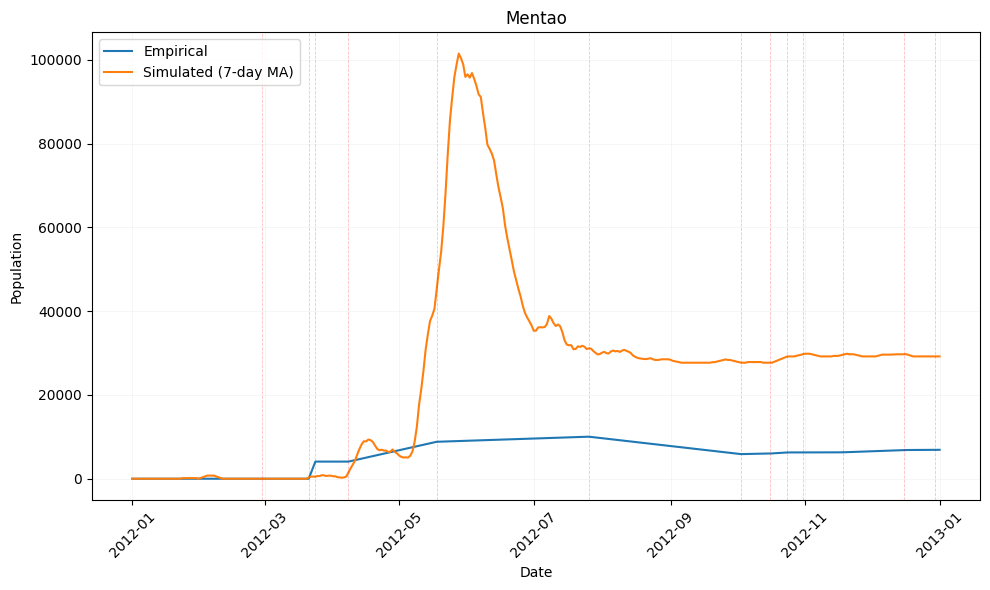

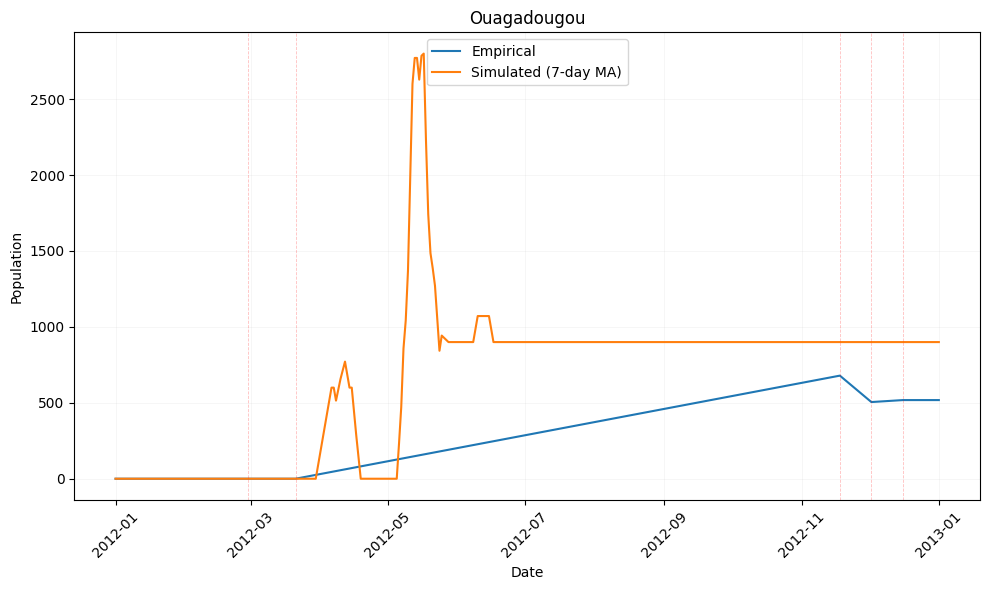

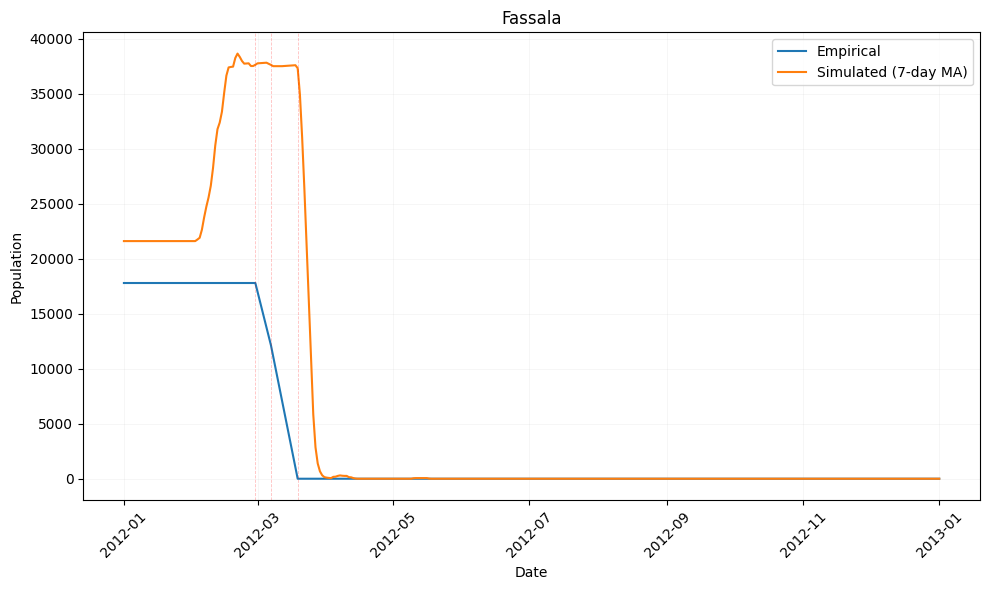

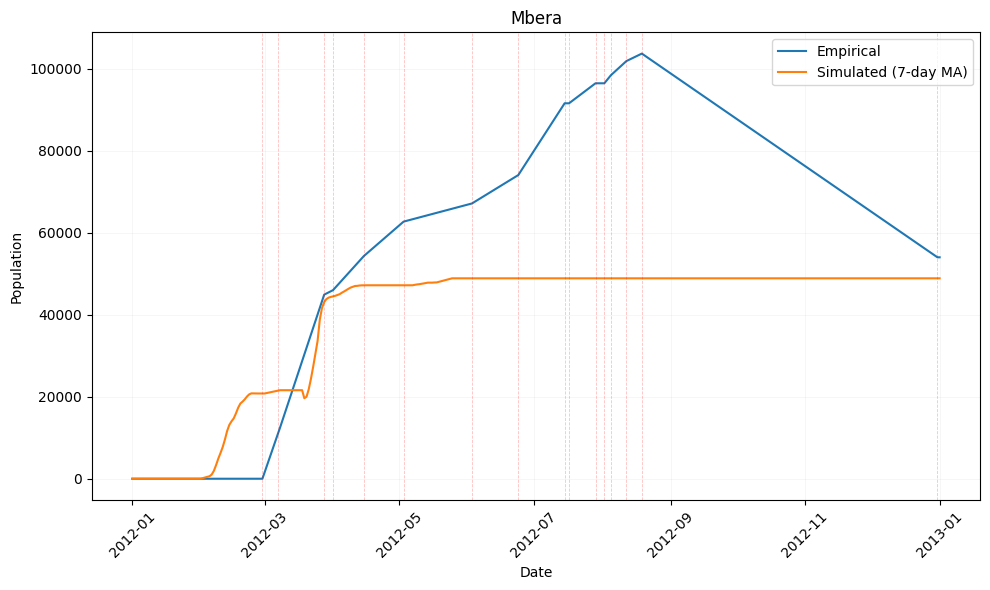

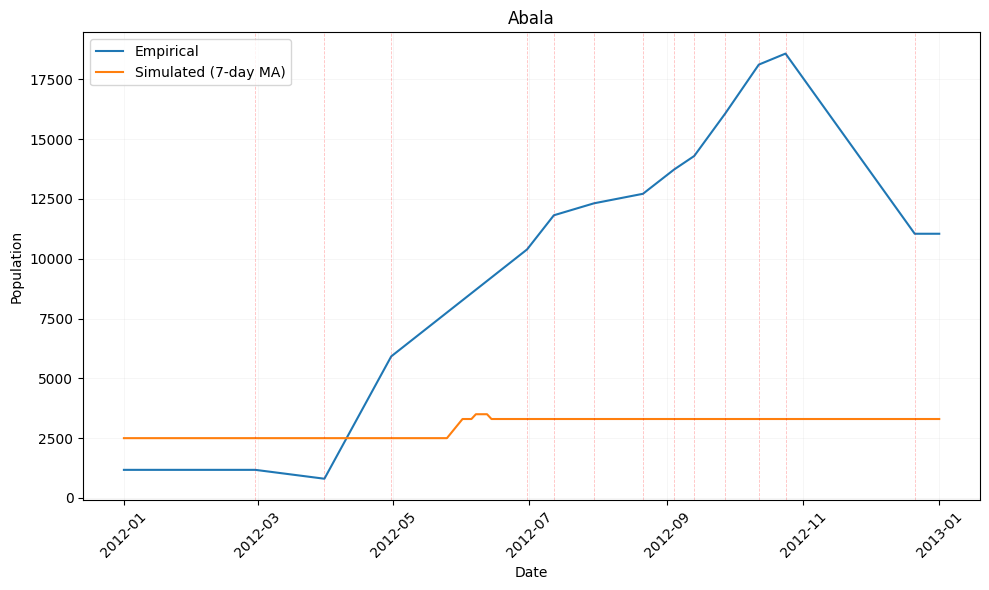

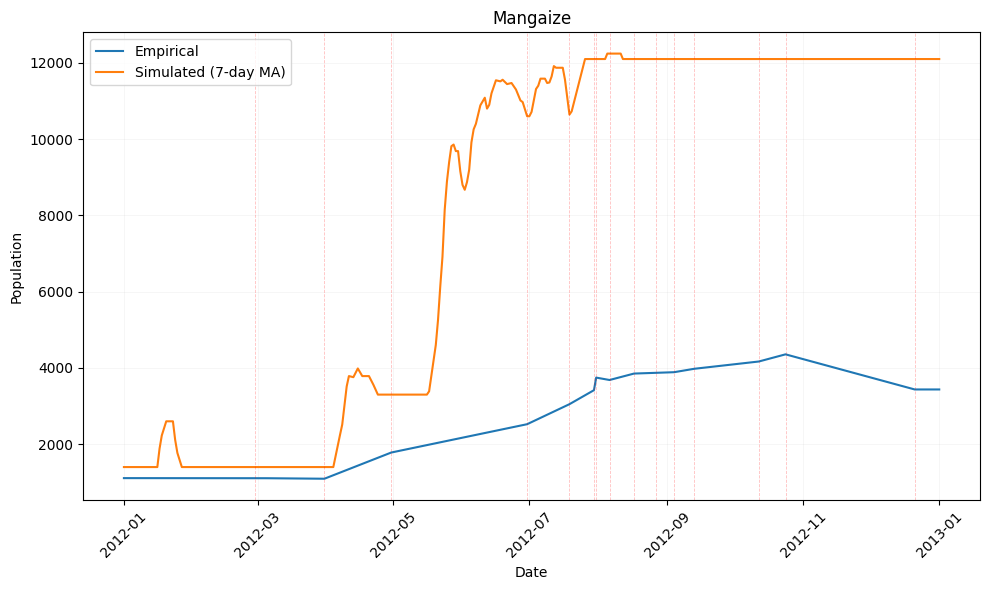

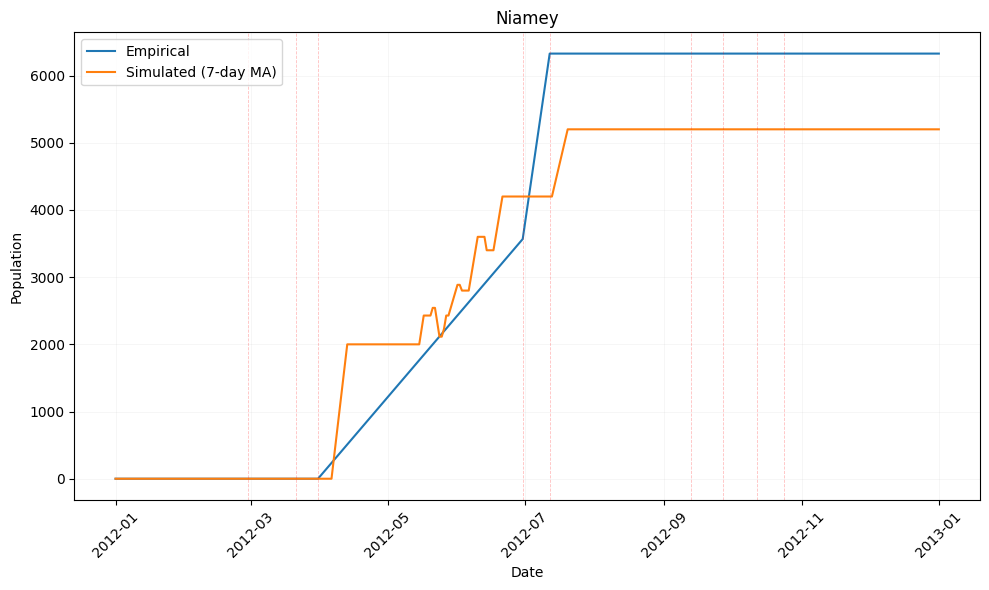

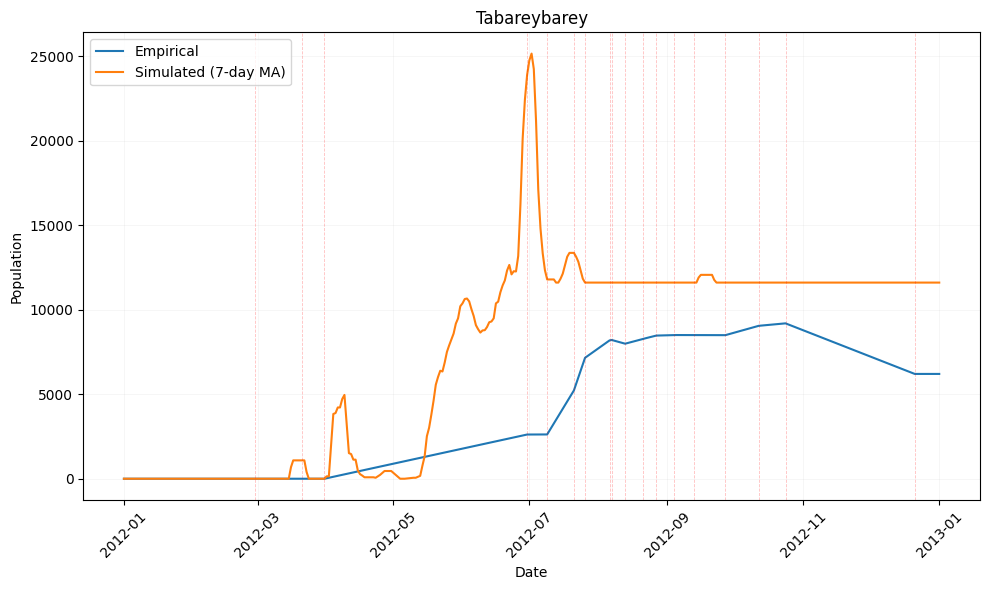

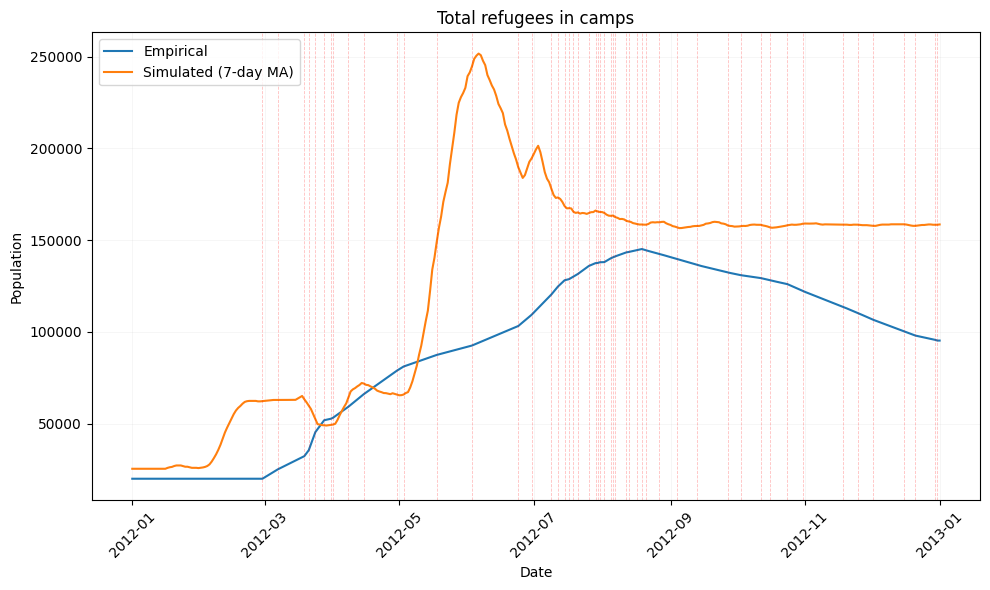

In [73]:
# Weekly smoothing
window_size = 7

# Example of Gaussian smoothing function (unused but kept)
def gaussian_smoothing(series, sigma):
    return gaussian_filter1d(series, sigma=sigma)

sigma = 2

# -----------------------
# Bobo
# -----------------------
bobo_smoothed = bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)']
bobo_sim_smoothed = moving_average(pd.Series(bobo_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, bobo_smoothed, label='Empirical')
plt.plot(date_sim, bobo_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[bobo['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Bobo')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Goudoubo
# -----------------------
goudoubo_smoothed = goudoubo['Nombre estimé de réfugiés maliens par période']
goudoubo_sim_smoothed = moving_average(pd.Series(goudoubo_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, goudoubo_smoothed, label='Empirical')
plt.plot(date_sim, goudoubo_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[goudoubo['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Goudoubo')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Mentao
# -----------------------
mentao_smoothed = mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)']
mentao_sim_smoothed = moving_average(pd.Series(mentao_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, mentao_smoothed, label='Empirical')
plt.plot(date_sim, mentao_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[mentao['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mentao')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Ouagadougou
# -----------------------
ouagadougou_smoothed = ouagadougou['Nombre estimé de réfugiés maliens par période']
ouagadougou_sim_smoothed = moving_average(pd.Series(ouagadougou_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, ouagadougou_smoothed, label='Empirical')
plt.plot(date_sim, ouagadougou_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[ouagadougou['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Ouagadougou')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Fassala
# -----------------------
fassala_smoothed = fassala['Réfugiés maliens']
fassala_sim_smoothed = moving_average(pd.Series(fassala_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, fassala_smoothed, label='Empirical')
plt.plot(date_sim, fassala_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[fassala['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Fassala')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Mbera
# -----------------------
mbera_smoothed = mbera['Réfugiés maliens']
mbera_sim_smoothed = moving_average(pd.Series(mbera_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, mbera_smoothed, label='Empirical')
plt.plot(date_sim, mbera_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[mbera['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mbera')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Abala
# -----------------------
abala_smoothed = abala['Nombre estimé de réfugiés maliens par période']
abala_sim_smoothed = moving_average(pd.Series(abala_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, abala_smoothed, label='Empirical')
plt.plot(date_sim, abala_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[abala['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Abala')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Mangaize
# -----------------------
mangaize_smoothed = mangaize['Nombre estimé de réfugiés maliens par période']
mangaize_sim_smoothed = moving_average(pd.Series(mangaize_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, mangaize_smoothed, label='Empirical')
plt.plot(date_sim, mangaize_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[mangaize['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mangaize')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Niamey
# -----------------------
niamey_smoothed = niamey['Nombre estimé de réfugiés maliens par période']
niamey_sim_smoothed = moving_average(pd.Series(niamey_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, niamey_smoothed, label='Empirical')
plt.plot(date_sim, niamey_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[niamey['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Niamey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# Tabareybarey
# -----------------------
tabareybarey_smoothed = tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)']
tabareybarey_sim_smoothed = moving_average(pd.Series(tabareybarey_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, tabareybarey_smoothed, label='Empirical')
plt.plot(date_sim, tabareybarey_sim_smoothed, label='Simulated (7-day MA)')
for d in date_sim[tabareybarey['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Tabareybarey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -----------------------
# TOTAL (also smoothed)
# -----------------------
camps = [bobo_sim,goudoubo_sim,mentao_sim,ouagadougou_sim,fassala_sim,mbera_sim,abala_sim,mangaize_sim,niamey_sim,tabareybarey_sim]

total_refugees_sim = [0]*len(camps[0])
for i in range(len(camps[0])):
    for camp in camps:
        total_refugees_sim[i] += camp[i]

# ✅ smooth total as well
total_refugees_sim_smoothed = moving_average(pd.Series(total_refugees_sim), window_size)

plt.figure(figsize=(10, 6))
plt.plot(date_sim, total_refugees_emp, label='Empirical')
plt.plot(date_sim, total_refugees_sim_smoothed, label='Simulated (7-day MA)')
is_real_total = (
    bobo['is_real'] |
    goudoubo['is_real'] |
    mentao['is_real'] |
    ouagadougou['is_real'] |
    fassala['is_real'] |
    mbera['is_real'] |
    abala['is_real'] |
    mangaize['is_real'] |
    niamey['is_real'] |
    tabareybarey['is_real']
)

for d in date_sim[is_real_total]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Total refugees in camps')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

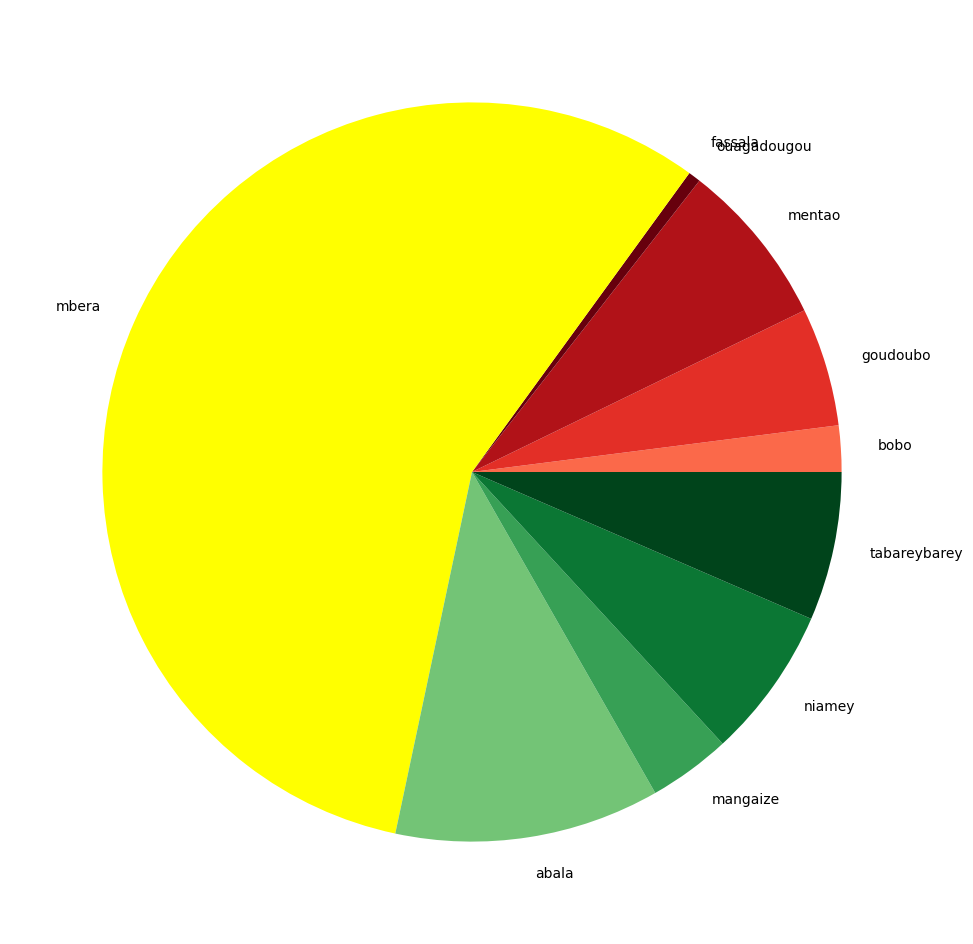

In [74]:
names = ['bobo', 'goudoubo', 'mentao', 'ouagadougou', 'fassala', 'mbera', 'abala', 'mangaize', 'niamey', 'tabareybarey']

values = [
    bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'].iloc[-1],
    goudoubo['Nombre estimé de réfugiés maliens par période'].iloc[-1],
    mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'].iloc[-1],
    ouagadougou['Nombre estimé de réfugiés maliens par période'].iloc[-1],
    fassala['Réfugiés maliens'].iloc[-1],
    mbera['Réfugiés maliens'].iloc[-1],
    abala['Nombre estimé de réfugiés maliens par période'].iloc[-1],
    mangaize['Nombre estimé de réfugiés maliens par période'].iloc[-1],
    niamey['Nombre estimé de réfugiés maliens par période'].iloc[-1],
    tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'].iloc[-1]
]

shades_red = plt.cm.Reds(np.linspace(0.5, 1, 4))
yellow_colors = [(1, 1, 0, i) for i in np.linspace(0.5, 1, 2)]
cmap_yellow = mcolors.LinearSegmentedColormap.from_list("yellow_shades", yellow_colors)
shades_yellow = cmap_yellow(np.linspace(0, 1, 2))

shades_green = plt.cm.Greens(np.linspace(0.5, 1, 4))

colors = [*shades_red, *shades_yellow, *shades_green]


plt.figure(figsize=(20, 12))
plt.pie(values, labels=names, colors=colors)
plt.show()

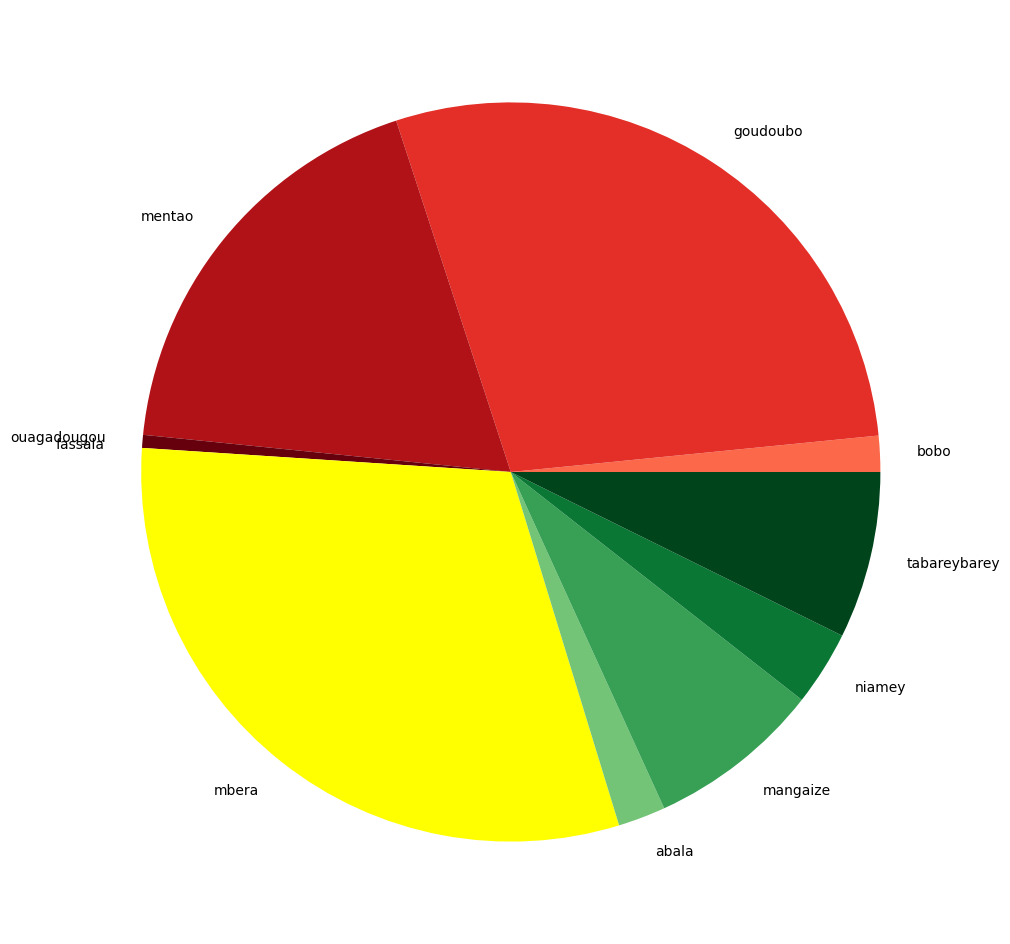

In [75]:
names = ['bobo', 'goudoubo', 'mentao', 'ouagadougou', 'fassala', 'mbera', 'abala', 'mangaize', 'niamey', 'tabareybarey']

values = [
    abs(bobo_sim.iloc[-1]),
    abs(goudoubo_sim.iloc[-1]),
    abs(mentao_sim.iloc[-1]),
    abs(ouagadougou_sim.iloc[-1]),
    abs(fassala_sim.iloc[-1]),
    abs(mbera_sim.iloc[-1]),
    abs(abala_sim.iloc[-1]),
    abs(mangaize_sim.iloc[-1]),
    abs(niamey_sim.iloc[-1]),
    abs(tabareybarey_sim.iloc[-1])
]



shades_red = plt.cm.Reds(np.linspace(0.5, 1, 4))
yellow_colors = [(1, 1, 0, i) for i in np.linspace(0.5, 1, 2)]
cmap_yellow = mcolors.LinearSegmentedColormap.from_list("yellow_shades", yellow_colors)
shades_yellow = cmap_yellow(np.linspace(0, 1, 2))
shades_green = plt.cm.Greens(np.linspace(0.5, 1, 4))

colors = [*shades_red, *shades_yellow, *shades_green]


plt.figure(figsize=(20, 12))
plt.pie(values, labels=names, colors=colors)
plt.show()

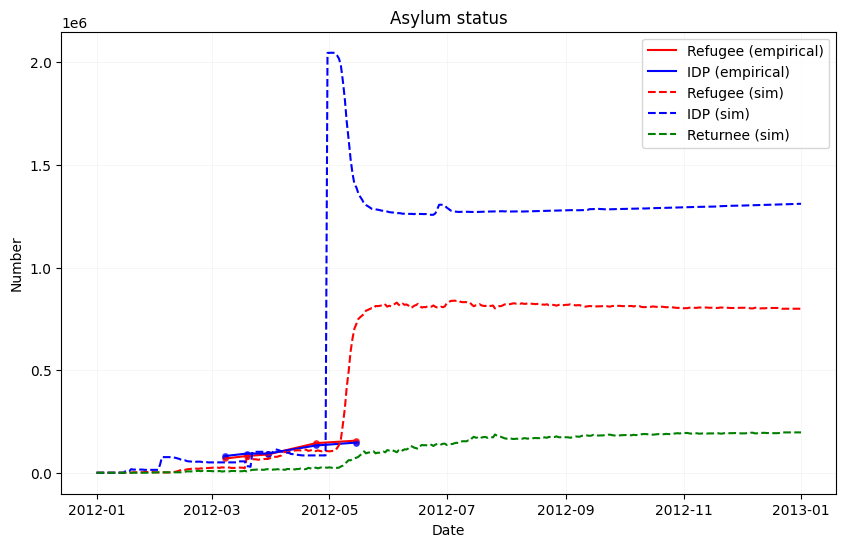

In [76]:

stat_sim = pd.read_csv("clean_run/Status_splits.csv")

date_stat_sim = pd.to_datetime(stat_sim['Date'])
ref_sim = stat_sim['Refugee']
ret_sim = stat_sim['Returnee']
idp_sim = stat_sim['IDP']

plt.figure(figsize=(10, 6))

# --- EMPIRICAL (solid + markers) ---
plt.plot(date, ref, label='Refugee (empirical)', color='red')
plt.scatter(date, ref, color='red', s=15, alpha=0.7)

plt.plot(date, idp, label='IDP (empirical)', color='blue')
plt.scatter(date, idp, color='blue', s=15, alpha=0.7)

# --- SIMULATION (dashed, no markers) ---
plt.plot(date_stat_sim, ref_sim, color='red', linestyle='--', label='Refugee (sim)')
plt.plot(date_stat_sim, idp_sim, color='blue', linestyle='--', label='IDP (sim)')
plt.plot(date_stat_sim, ret_sim, color='green', linestyle='--', label='Returnee (sim)')

plt.xlabel('Date')
plt.ylabel('Number')
plt.title('Asylum status')

# Light grid (your style)
plt.grid(True, linewidth=0.5, alpha=0.15)

plt.legend()
plt.show()








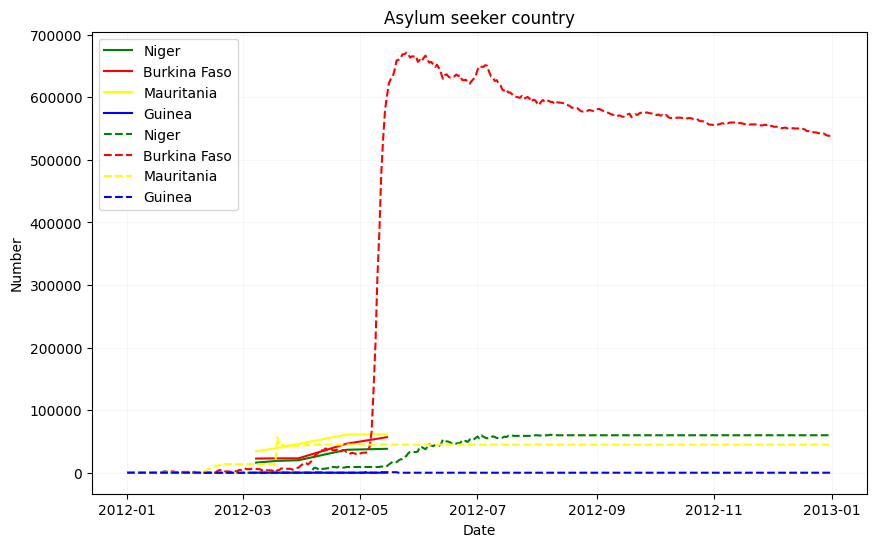

In [77]:
count_sim = pd.read_csv("clean_run/Country_split_refugees.csv", encoding='latin1')

date_count_sim = pd.to_datetime(count_sim['Date'])
nig_sim = count_sim['Niger']
bf_sim = count_sim['Burkina Faso']
mau_sim = count_sim['Mauritania']
gui_sim =count_sim['Guinea']


plt.figure(figsize=(10, 6))


plt.plot(date, nig, label='Niger', color='Green')
plt.plot(date, bf, label='Burkina Faso',color='Red')
plt.plot(date, mau, label='Mauritania',color='Yellow')
plt.plot(date, gui, label='Guinea',color='Blue')

plt.plot(date_count_sim, nig_sim, label='Niger', color='Green',linestyle='--')
plt.plot(date_count_sim, bf_sim, label='Burkina Faso',color='Red',linestyle='--')
plt.plot(date_count_sim, mau_sim, label='Mauritania',color='Yellow',linestyle='--')
plt.plot(date_count_sim, gui_sim, label='Guinea',color='Blue',linestyle='--')





plt.xlabel('Date')
plt.ylabel('Number')
plt.title('Asylum seeker country')
plt.legend()
# Light grid (your style)
plt.grid(True, linewidth=0.5, alpha=0.15)

plt.show()

In [78]:
flee = pd.read_csv("Fleeresults.csv")

flee.columns

Index(['Day', 'Mbera sim', 'Mbera data', 'Mbera error', 'Mentao sim',
       'Mentao data', 'Mentao error', 'Bobo-Dioulasso sim',
       'Bobo-Dioulasso data', 'Bobo-Dioulasso error', 'Abala sim',
       'Abala data', 'Abala error', 'Mangaize sim', 'Mangaize data',
       'Mangaize error', 'Niamey sim', 'Niamey data', 'Niamey error',
       'Tabareybarey sim', 'Tabareybarey data', 'Tabareybarey error',
       'Total error', 'refugees in camps (UNHCR)',
       'total refugees (simulation)', 'raw UNHCR refugee count',
       'retrofitted time', 'refugees in camps (simulation)', 'refugee_debt',
       'Total error (retrofitted)'],
      dtype='object')

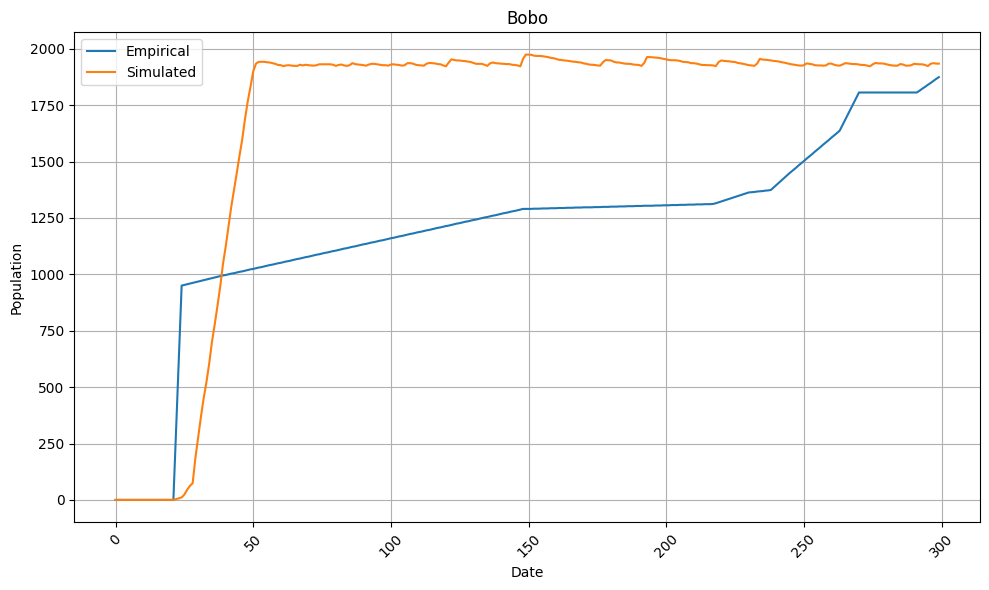

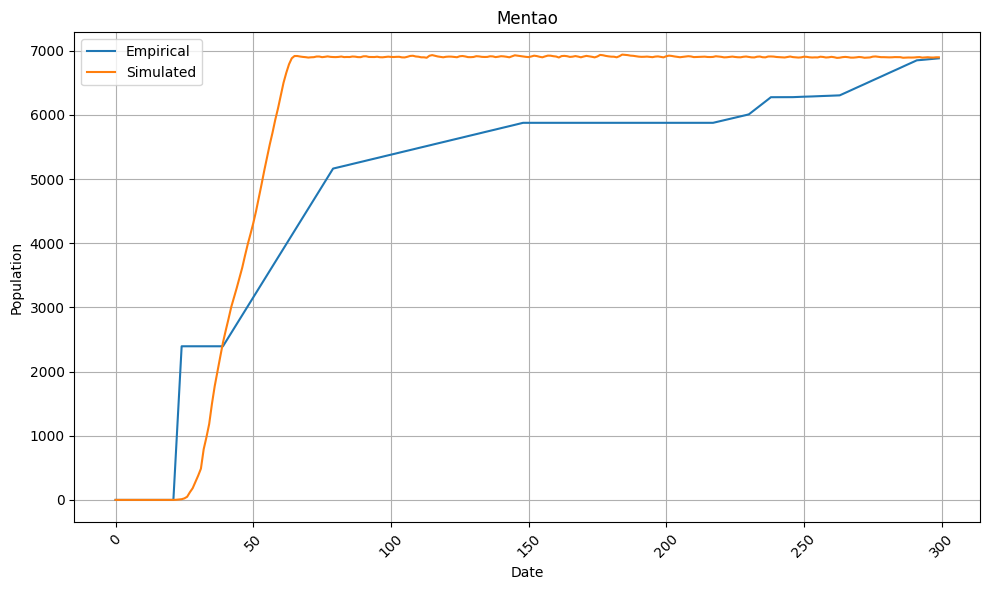

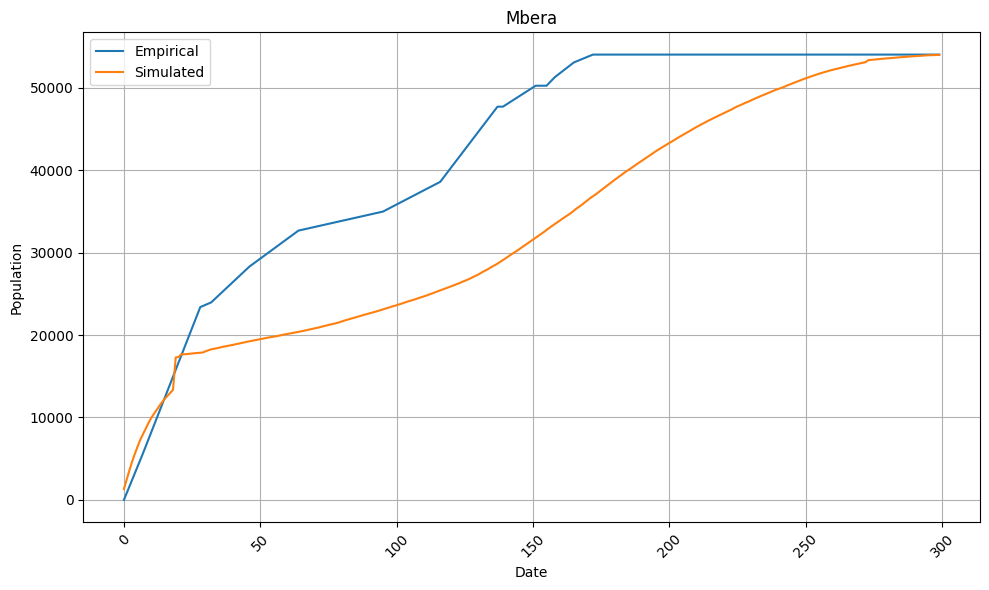

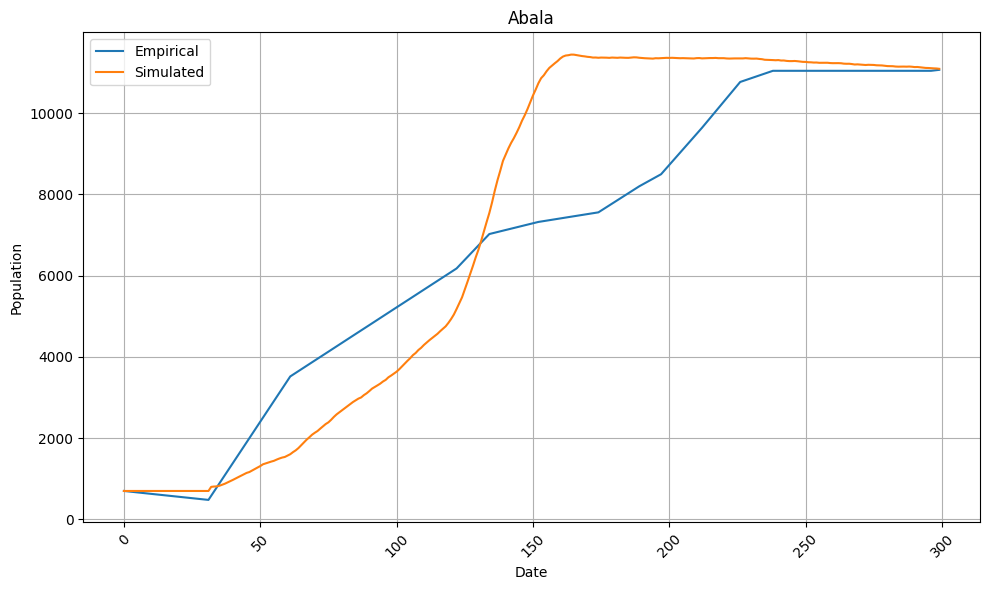

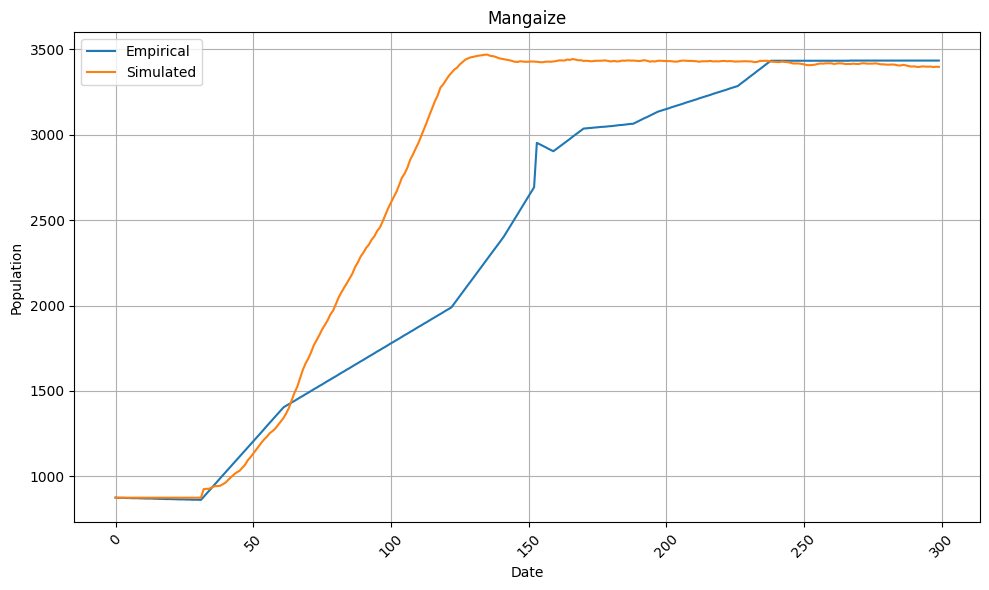

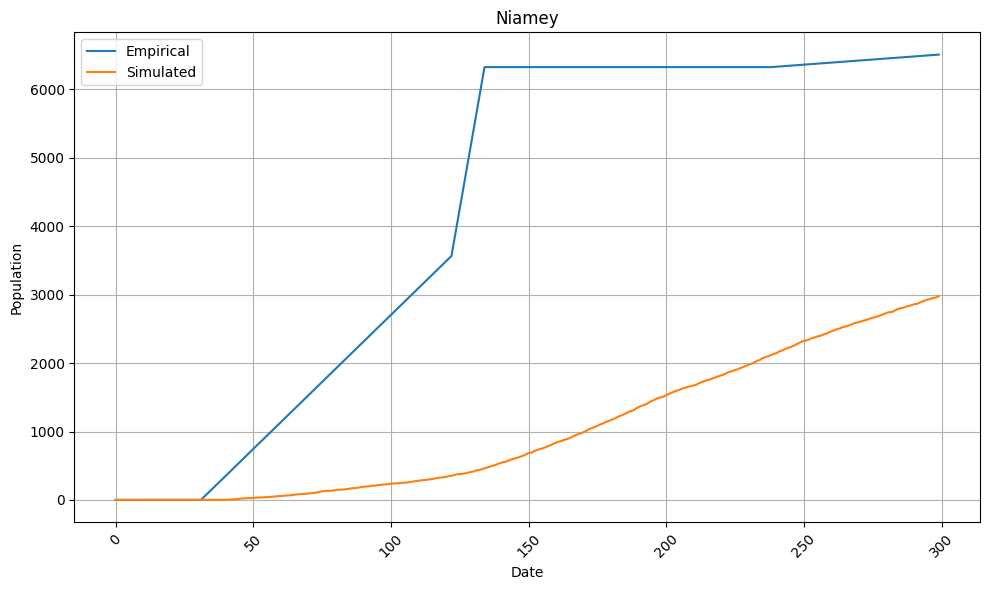

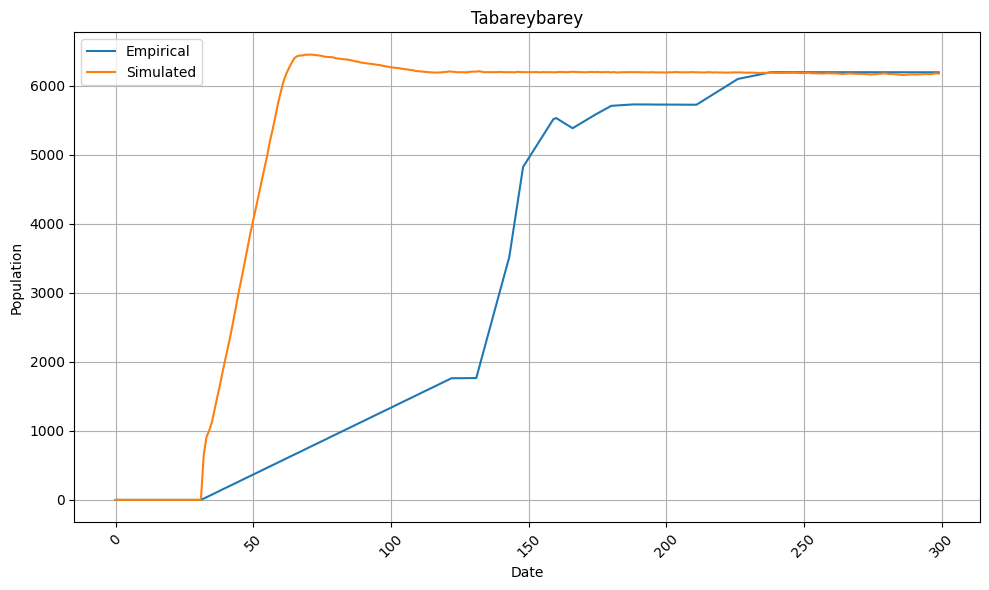

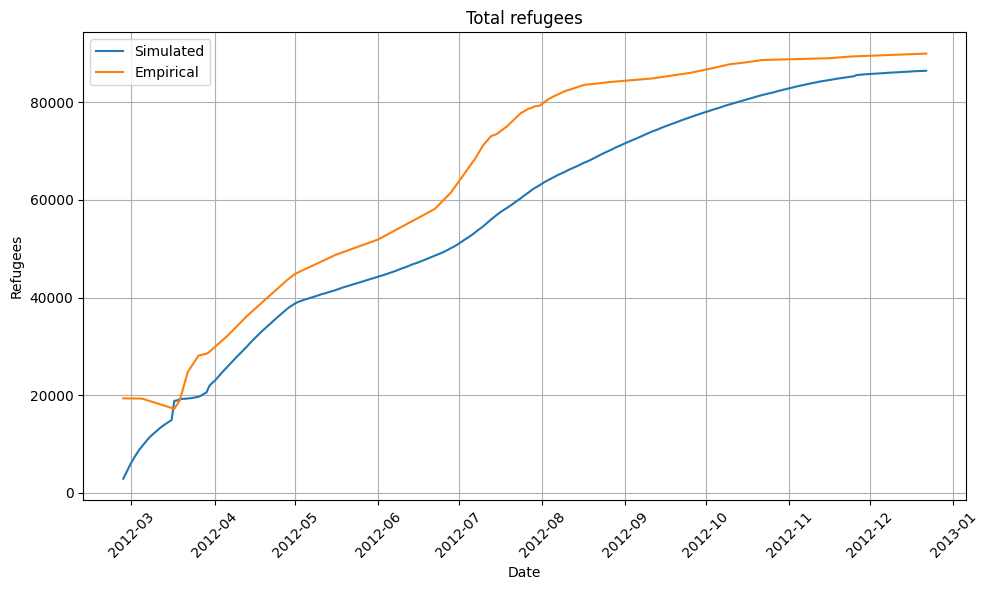

In [79]:
flee['Date'] = pd.to_datetime('2012-01-01') + pd.to_timedelta(flee['Day'], unit='D') + pd.Timedelta(days=57)

plt.figure(figsize=(10, 6))
plt.plot(flee['Day'],flee['Bobo-Dioulasso data'], label='Empirical')
plt.plot(flee['Day'],flee['Bobo-Dioulasso sim'], label='Simulated')
plt.title('Bobo')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(flee['Day'],flee['Mentao data'], label='Empirical')
plt.plot(flee['Day'],flee['Mentao sim'], label='Simulated')
plt.title('Mentao')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(flee['Day'],flee['Mbera data'], label='Empirical')
plt.plot(flee['Day'],flee['Mbera sim'], label='Simulated')
plt.title('Mbera')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(flee['Day'],flee['Abala data'], label='Empirical')
plt.plot(flee['Day'],flee['Abala sim'], label='Simulated')
plt.title('Abala')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(flee['Day'],flee['Mangaize data'], label='Empirical')
plt.plot(flee['Day'],flee['Mangaize sim'], label='Simulated')
plt.title('Mangaize')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(flee['Day'],flee['Niamey data'], label='Empirical')
plt.plot(flee['Day'],flee['Niamey sim'], label='Simulated')
plt.title('Niamey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(flee['Day'],flee['Tabareybarey data'], label='Empirical')
plt.plot(flee['Day'],flee['Tabareybarey sim'], label='Simulated')
plt.title('Tabareybarey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(flee['Date'],flee['refugees in camps (simulation)'],label ='Simulated' )
plt.plot(flee['Date'],flee['raw UNHCR refugee count'], label='Empirical')
plt.title('Total refugees')
plt.xlabel('Date')
plt.ylabel('Refugees')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



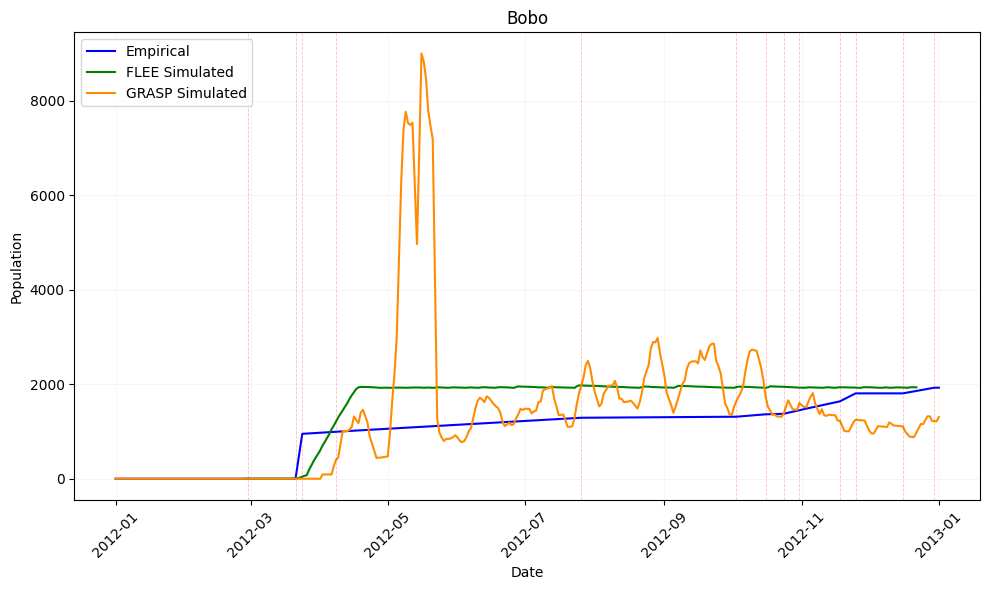

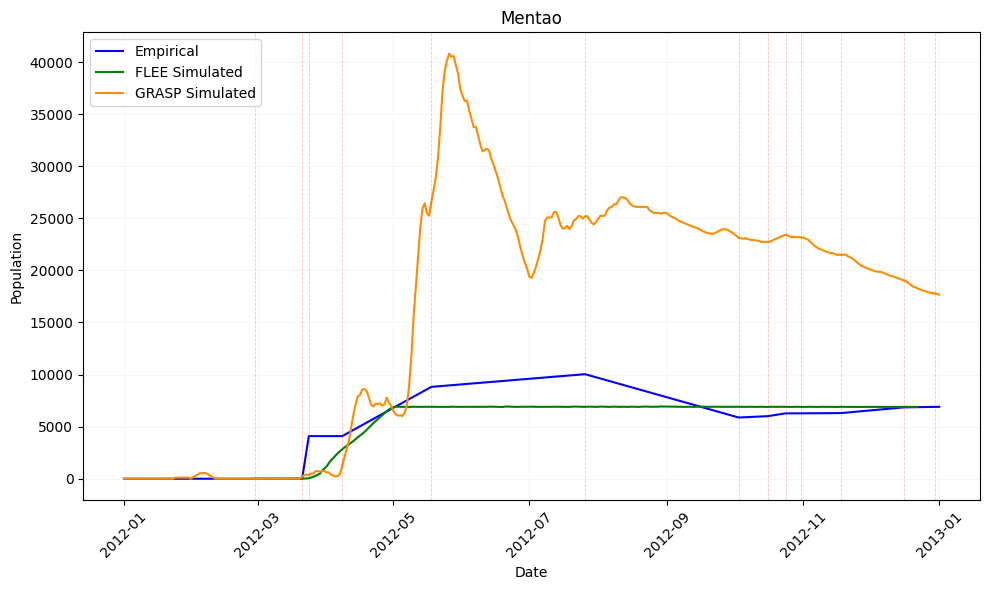

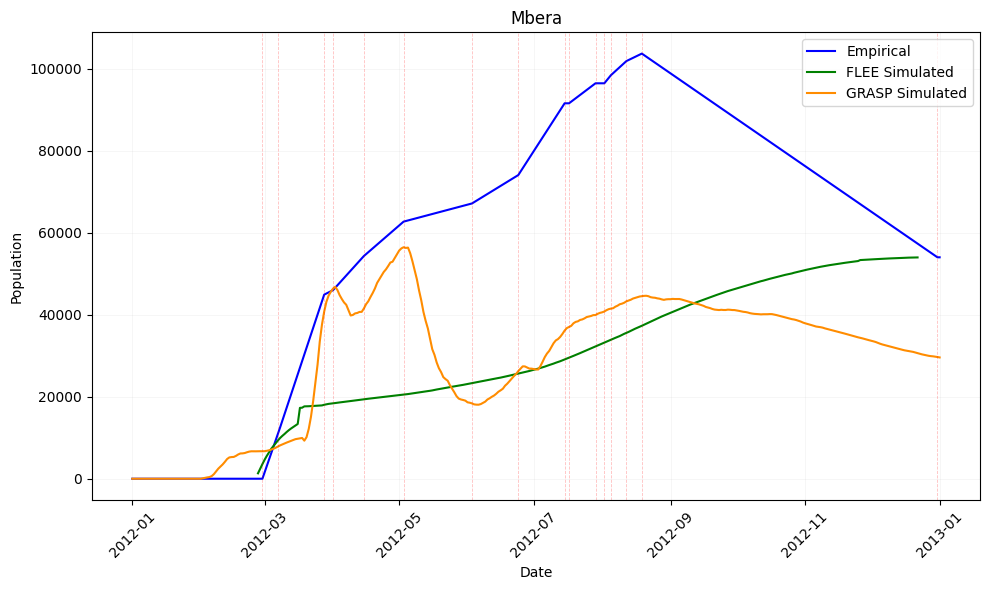

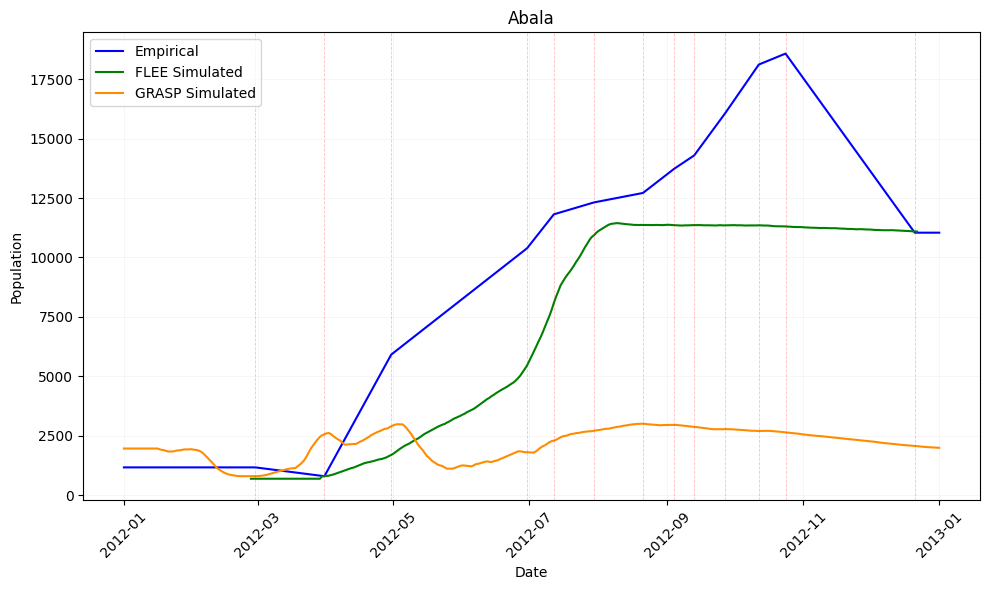

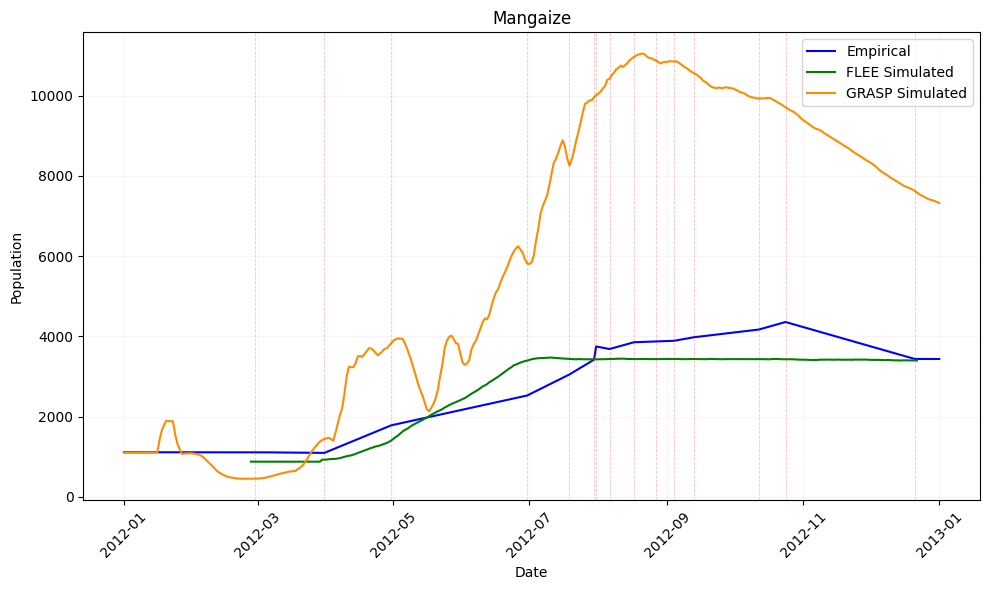

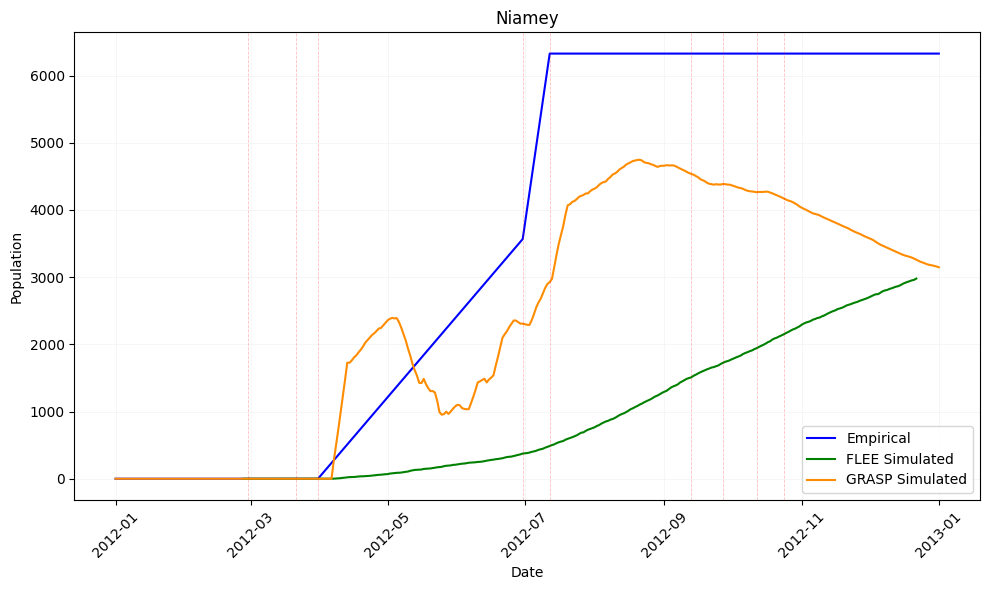

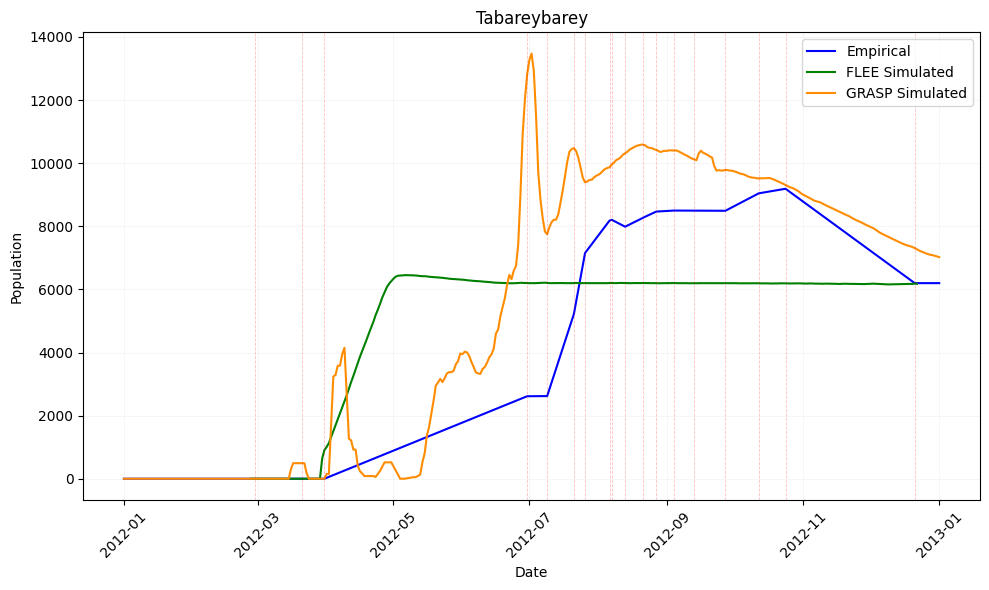

In [80]:
# 7-day smoothing for GRASP only
window_size = 7

def smooth(series):
    return moving_average(pd.Series(series), window_size)
# -----------------------
# Bobo
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(date_sim, bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'], label='Empirical', color='b')
plt.plot(flee['Date'], flee['Bobo-Dioulasso sim'], label='FLEE Simulated', color='g')
plt.plot(date_sim, smooth(bobo_upscaled), label='GRASP Simulated', color='darkorange')
for d in date_sim[bobo['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Bobo')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------
# Mentao
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(date_sim, mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'], label='Empirical', color='b')
plt.plot(flee['Date'], flee['Mentao sim'], label='FLEE Simulated', color='g')
plt.plot(date_sim, smooth(mentao_upscaled), label='GRASP Simulated', color='darkorange')
for d in date_sim[mentao['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mentao')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------
# Mbera
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(date_sim, mbera['Réfugiés maliens'], label='Empirical', color='b')
plt.plot(flee['Date'], flee['Mbera sim'], label='FLEE Simulated', color='g')
plt.plot(date_sim, smooth(mbera_upscaled), label='GRASP Simulated', color='darkorange')
for d in date_sim[mbera['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mbera')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------
# Abala
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(date_sim, abala['Nombre estimé de réfugiés maliens par période'], label='Empirical', color='b')
plt.plot(flee['Date'], flee['Abala sim'], label='FLEE Simulated', color='g')
plt.plot(date_sim, smooth(abala_upscaled), label='GRASP Simulated', color='darkorange')
for d in date_sim[abala['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Abala')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------
# Mangaize
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(date_sim, mangaize['Nombre estimé de réfugiés maliens par période'], label='Empirical', color='b')
plt.plot(flee['Date'], flee['Mangaize sim'], label='FLEE Simulated', color='g')
plt.plot(date_sim, smooth(mangaize_upscaled), label='GRASP Simulated', color='darkorange')
for d in date_sim[mangaize['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Mangaize')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------
# Niamey
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(date_sim, niamey['Nombre estimé de réfugiés maliens par période'], label='Empirical', color='b')
plt.plot(flee['Date'], flee['Niamey sim'], label='FLEE Simulated', color='g')
plt.plot(date_sim, smooth(niamey_upscaled), label='GRASP Simulated', color='darkorange')
for d in date_sim[niamey['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Niamey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -----------------------
# Tabareybarey
# -----------------------
plt.figure(figsize=(10, 6))
plt.plot(date_sim, tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'], label='Empirical', color='b')
plt.plot(flee['Date'], flee['Tabareybarey sim'], label='FLEE Simulated', color='g')
plt.plot(date_sim, smooth(tabareybarey_upscaled), label='GRASP Simulated', color='darkorange')
for d in date_sim[tabareybarey['is_real'].values]:
    plt.axvline(x=d, color='red', linestyle='--', linewidth=0.6, alpha=0.25)
plt.title('Tabareybarey')
plt.xlabel('Date')
plt.ylabel('Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:26: RuntimeWarning: divide by zero encountered in divide
  difference_flee_bobo = np.abs((bobo_emp[58:358] - bobo_flee[58:358]) / bobo_emp[58:358])
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:27: RuntimeWarning: invalid value encountered in divide
  difference_grasp_bobo = np.abs((bobo_emp - bobo_grasp) / bobo_emp)


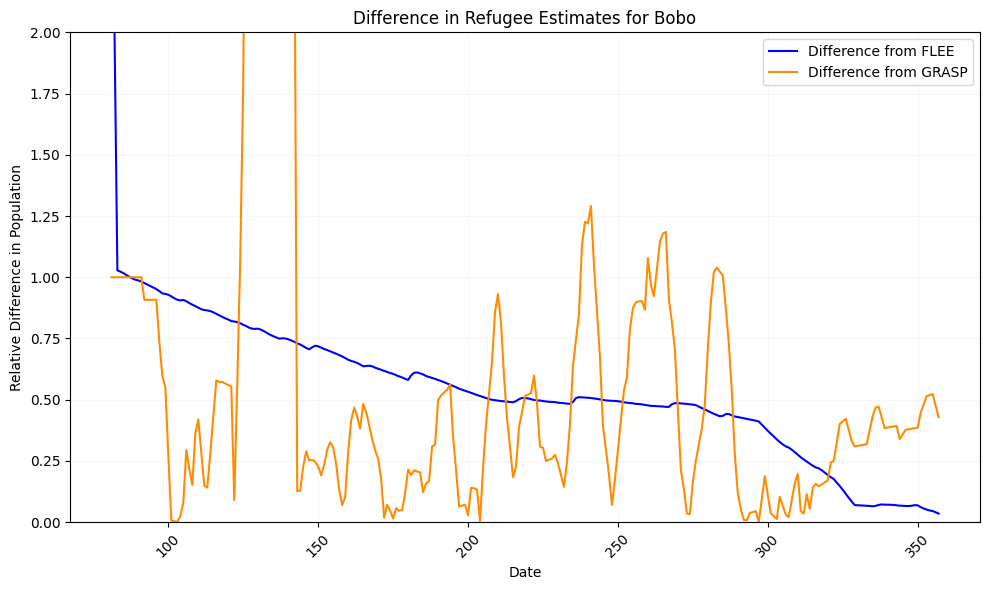

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:49: RuntimeWarning: divide by zero encountered in divide
  difference_flee_mentao = np.abs((mentao_emp[58:358] - mentao_flee[58:358]) / mentao_emp[58:358])
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:50: RuntimeWarning: divide by zero encountered in divide
  difference_grasp_mentao = np.abs((mentao_emp - mentao_grasp) / mentao_emp)
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:50: RuntimeWarning: invalid value encountered in divide
  difference_grasp_mentao = np.abs((mentao_emp - mentao_grasp) / mentao_emp)


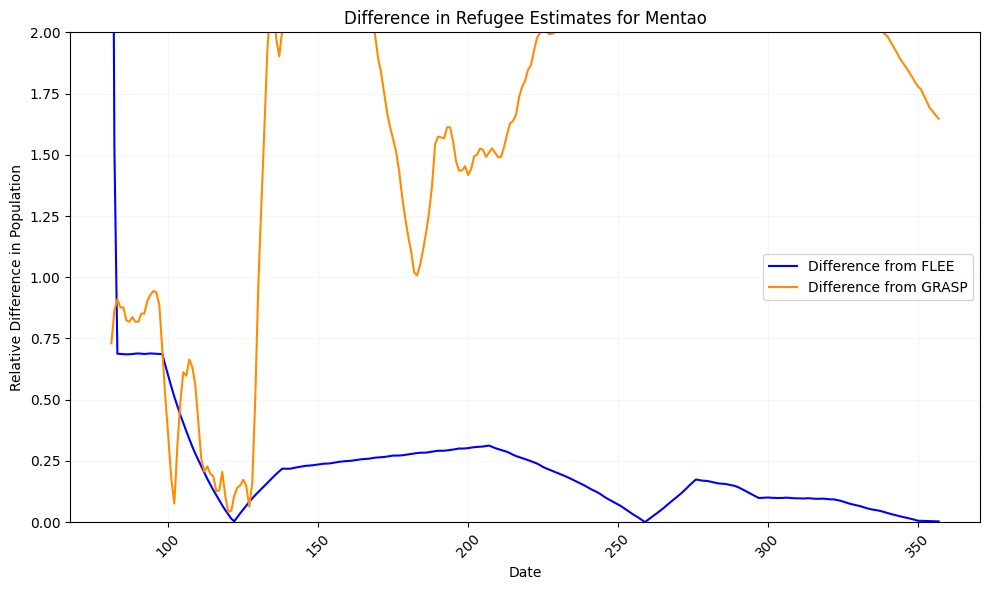

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:72: RuntimeWarning: divide by zero encountered in divide
  difference_flee_mbera = np.abs((mbera_emp[58:358] - mbera_flee[58:358]) / mbera_emp[58:358])
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:73: RuntimeWarning: divide by zero encountered in divide
  difference_grasp_mbera = np.abs((mbera_emp - mbera_grasp) / mbera_emp)
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:73: RuntimeWarning: invalid value encountered in divide
  difference_grasp_mbera = np.abs((mbera_emp - mbera_grasp) / mbera_emp)


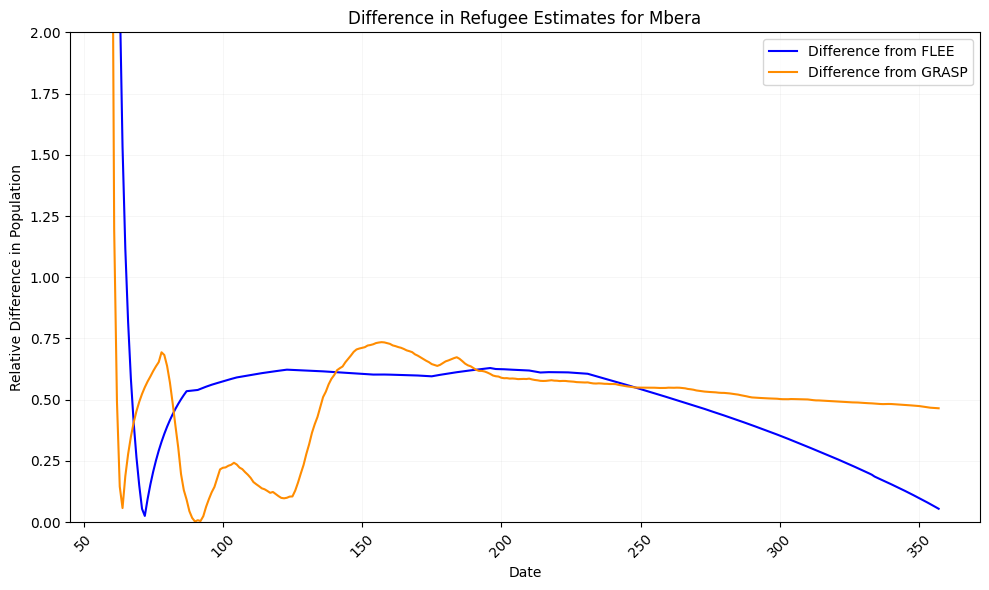

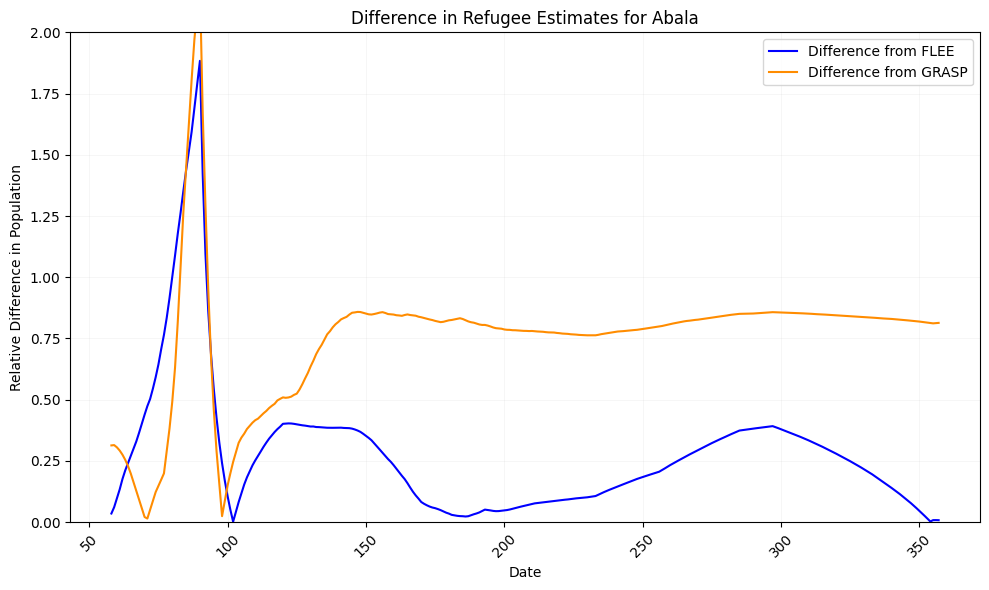

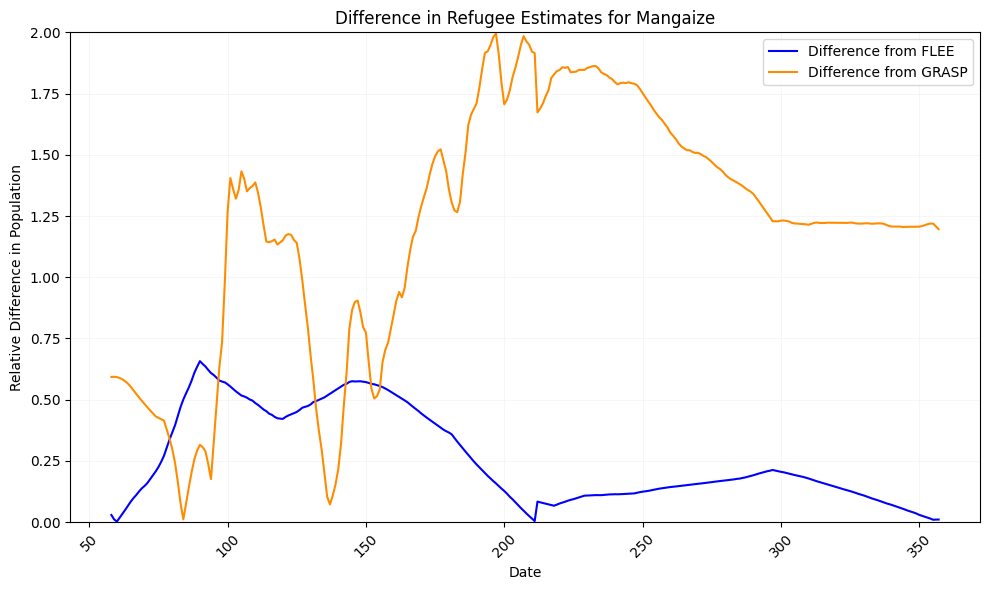

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:141: RuntimeWarning: divide by zero encountered in divide
  difference_flee_niamey = np.abs((niamey_emp[58:358] - niamey_flee[58:358]) / niamey_emp[58:358])
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:142: RuntimeWarning: invalid value encountered in divide
  difference_grasp_niamey = np.abs((niamey_emp - niamey_grasp) / niamey_emp)


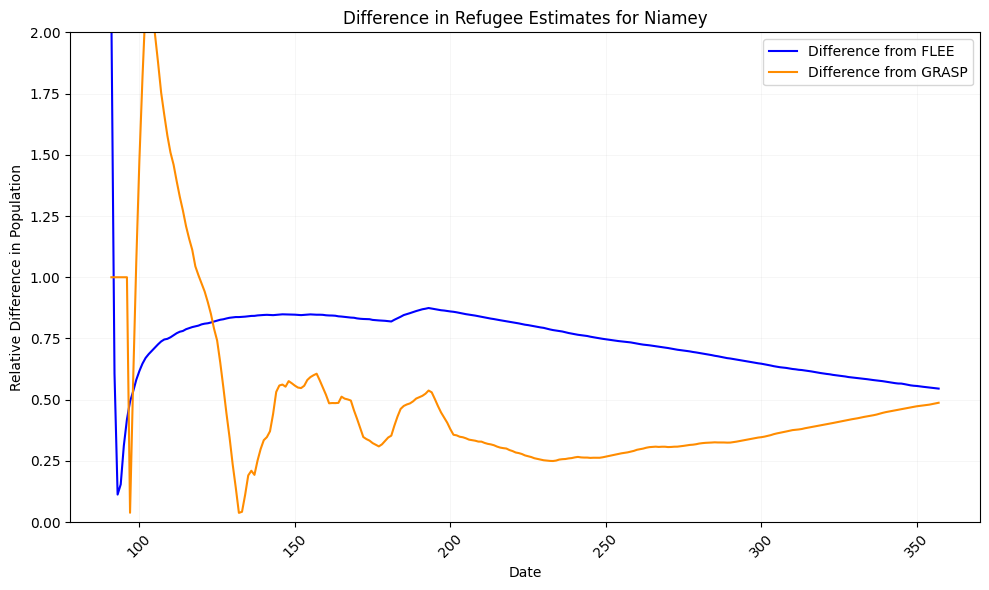

/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:164: RuntimeWarning: divide by zero encountered in divide
  difference_flee_tab = np.abs((tab_emp[58:358] - tab_flee[58:358]) / tab_emp[58:358])
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:165: RuntimeWarning: divide by zero encountered in divide
  difference_grasp_tab = np.abs((tab_emp - tab_grasp) / tab_emp)
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/3901742926.py:165: RuntimeWarning: invalid value encountered in divide
  difference_grasp_tab = np.abs((tab_emp - tab_grasp) / tab_emp)


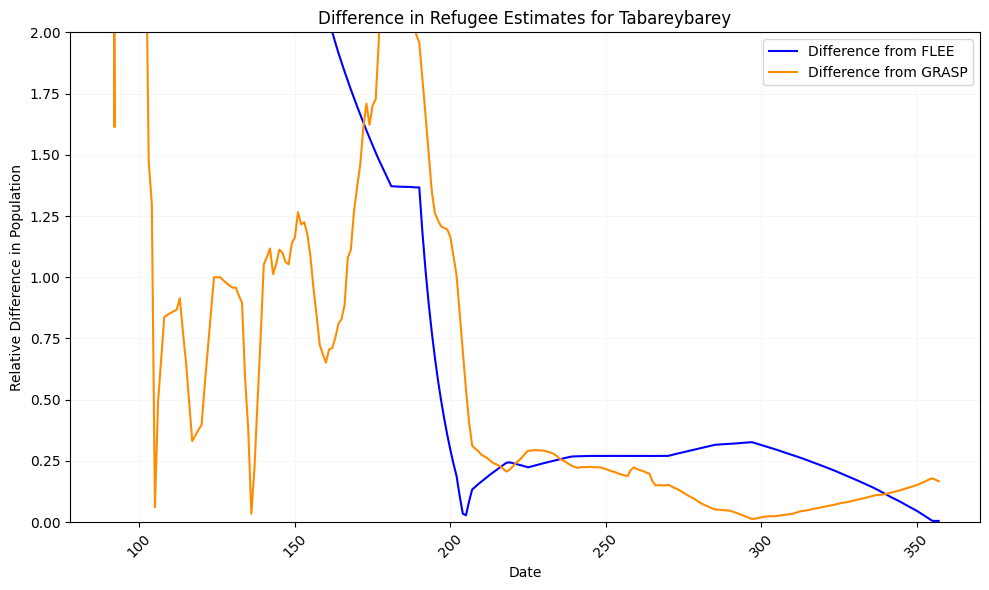

In [81]:
# -----------------------
# 7-day smoothing (GRASP only)
# -----------------------
window_size = 7

def smooth(series):
    return moving_average(pd.Series(series), window_size).values

def align(series, target_length):
    """
    Interpolate a series onto a target length.
    """
    return np.interp(
        np.arange(target_length),
        np.linspace(0, target_length - 1, len(series)),
        series
    )

# ==========================================================
# Bobo
# ==========================================================
bobo_emp = bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'].values
bobo_flee = align(flee['Bobo-Dioulasso sim'].values, len(bobo_emp))
bobo_grasp = smooth(bobo_upscaled)

difference_flee_bobo = np.abs((bobo_emp[58:358] - bobo_flee[58:358]) / bobo_emp[58:358])
difference_grasp_bobo = np.abs((bobo_emp - bobo_grasp) / bobo_emp)

plt.figure(figsize=(10,6))
plt.plot(bobo.index[58:358], difference_flee_bobo, label='Difference from FLEE', color='b')
plt.plot(bobo.index[58:358], difference_grasp_bobo[58:358], label='Difference from GRASP', color='darkorange')
plt.title('Difference in Refugee Estimates for Bobo')
plt.xlabel('Date')
plt.ylabel('Relative Difference in Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

# ==========================================================
# Mentao
# ==========================================================
mentao_emp = mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'].values
mentao_flee = align(flee['Mentao sim'].values, len(mentao_emp))
mentao_grasp = smooth(mentao_upscaled)

difference_flee_mentao = np.abs((mentao_emp[58:358] - mentao_flee[58:358]) / mentao_emp[58:358])
difference_grasp_mentao = np.abs((mentao_emp - mentao_grasp) / mentao_emp)

plt.figure(figsize=(10,6))
plt.plot(mentao.index[58:358], difference_flee_mentao, label='Difference from FLEE', color='b')
plt.plot(mentao.index[58:358], difference_grasp_mentao[58:358], label='Difference from GRASP', color='darkorange')
plt.title('Difference in Refugee Estimates for Mentao')
plt.xlabel('Date')
plt.ylabel('Relative Difference in Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

# ==========================================================
# Mbera
# ==========================================================
mbera_emp = mbera['Réfugiés maliens'].values
mbera_flee = align(flee['Mbera sim'].values, len(mbera_emp))
mbera_grasp = smooth(mbera_upscaled)

difference_flee_mbera = np.abs((mbera_emp[58:358] - mbera_flee[58:358]) / mbera_emp[58:358])
difference_grasp_mbera = np.abs((mbera_emp - mbera_grasp) / mbera_emp)

plt.figure(figsize=(10,6))
plt.plot(mbera.index[58:358], difference_flee_mbera, label='Difference from FLEE', color='b')
plt.plot(mbera.index[58:358], difference_grasp_mbera[58:358], label='Difference from GRASP', color='darkorange')
plt.title('Difference in Refugee Estimates for Mbera')
plt.xlabel('Date')
plt.ylabel('Relative Difference in Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

# ==========================================================
# Abala
# ==========================================================
abala_emp = abala['Nombre estimé de réfugiés maliens par période'].values
abala_flee = align(flee['Abala sim'].values, len(abala_emp))
abala_grasp = smooth(abala_upscaled)

difference_flee_abala = np.abs((abala_emp[58:358] - abala_flee[58:358]) / abala_emp[58:358])
difference_grasp_abala = np.abs((abala_emp - abala_grasp) / abala_emp)

plt.figure(figsize=(10,6))
plt.plot(abala.index[58:358], difference_flee_abala, label='Difference from FLEE', color='b')
plt.plot(abala.index[58:358], difference_grasp_abala[58:358], label='Difference from GRASP', color='darkorange')
plt.title('Difference in Refugee Estimates for Abala')
plt.xlabel('Date')
plt.ylabel('Relative Difference in Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

# ==========================================================
# Mangaize
# ==========================================================
mangaize_emp = mangaize['Nombre estimé de réfugiés maliens par période'].values
mangaize_flee = align(flee['Mangaize sim'].values, len(mangaize_emp))
mangaize_grasp = smooth(mangaize_upscaled)

difference_flee_mangaize = np.abs((mangaize_emp[58:358] - mangaize_flee[58:358]) / mangaize_emp[58:358])
difference_grasp_mangaize = np.abs((mangaize_emp - mangaize_grasp) / mangaize_emp)

plt.figure(figsize=(10,6))
plt.plot(mangaize.index[58:358], difference_flee_mangaize, label='Difference from FLEE', color='b')
plt.plot(mangaize.index[58:358], difference_grasp_mangaize[58:358], label='Difference from GRASP', color='darkorange')
plt.title('Difference in Refugee Estimates for Mangaize')
plt.xlabel('Date')
plt.ylabel('Relative Difference in Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

# ==========================================================
# Niamey
# ==========================================================
niamey_emp = niamey['Nombre estimé de réfugiés maliens par période'].values
niamey_flee = align(flee['Niamey sim'].values, len(niamey_emp))
niamey_grasp = smooth(niamey_upscaled)

difference_flee_niamey = np.abs((niamey_emp[58:358] - niamey_flee[58:358]) / niamey_emp[58:358])
difference_grasp_niamey = np.abs((niamey_emp - niamey_grasp) / niamey_emp)

plt.figure(figsize=(10,6))
plt.plot(niamey.index[58:358], difference_flee_niamey, label='Difference from FLEE', color='b')
plt.plot(niamey.index[58:358], difference_grasp_niamey[58:358], label='Difference from GRASP', color='darkorange')
plt.title('Difference in Refugee Estimates for Niamey')
plt.xlabel('Date')
plt.ylabel('Relative Difference in Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

# ==========================================================
# Tabareybarey
# ==========================================================
tab_emp = tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'].values
tab_flee = align(flee['Tabareybarey sim'].values, len(tab_emp))
tab_grasp = smooth(tabareybarey_upscaled)

difference_flee_tab = np.abs((tab_emp[58:358] - tab_flee[58:358]) / tab_emp[58:358])
difference_grasp_tab = np.abs((tab_emp - tab_grasp) / tab_emp)

plt.figure(figsize=(10,6))
plt.plot(tabareybarey.index[58:358], difference_flee_tab, label='Difference from FLEE', color='b')
plt.plot(tabareybarey.index[58:358], difference_grasp_tab[58:358], label='Difference from GRASP', color='darkorange')
plt.title('Difference in Refugee Estimates for Tabareybarey')
plt.xlabel('Date')
plt.ylabel('Relative Difference in Population')
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.15)
plt.xticks(rotation=45)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

In [82]:
print(np.mean([x for x in difference_grasp_mbera if not np.isnan(x) and x != np.inf]))





0.5009810116226402


/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/4234171540.py:74: RuntimeWarning: invalid value encountered in divide
  acc_dic[camp]['Precision'] = np.where(denominator != 0, tps / denominator, 1)


300
empnorms: [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.008142767400738075, 0.015014337231731996, 0.020890833186244705, 0.020237952445220298, 0.01962837599826121, 0.019057933710928406, 0.018522974232493914, 0.01848579913272677, 0.01844900199716516, 0.018412577090744803, 0.01828208626284962, 0.018046169565217995, 0.017817653718583588, 0.01759619584722803, 0.01738147393354301, 0.017173185255717177, 0.016971044963774846, 0.0167747847798806, 0.01654684625795492, 0.016326203439422312, 0.016112511567677505, 0.015905447271115043, 0.015704706930329805, 0.01551000519266944, 0.015321073618854607, 0.015166802209334215, 0.015016401512361584, 0.014869727656937734, 0.014726643814884085, 0.014587019775099666, 0.014450731548333035, 0.01431766099994757, 0.014187695508393714, 0.014060727647313122, 0.013936654889388597, 0.01381537933022404, 0.01369680743069142, 0.013580849776319813, 0.013467420852425638, 0.01335643883379575, 0.013265757033198029, 0.013176752045409842, 0.01

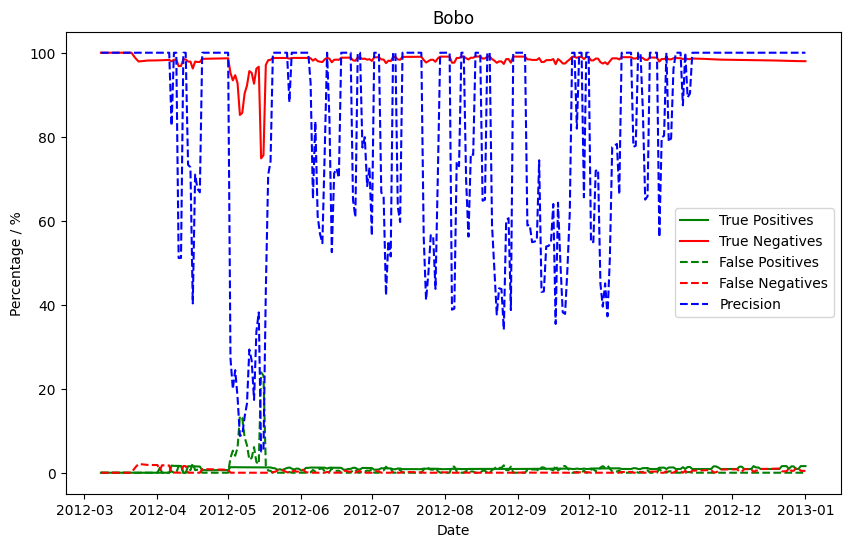

8.311708075305189
Mean precision is 8.311708075305189


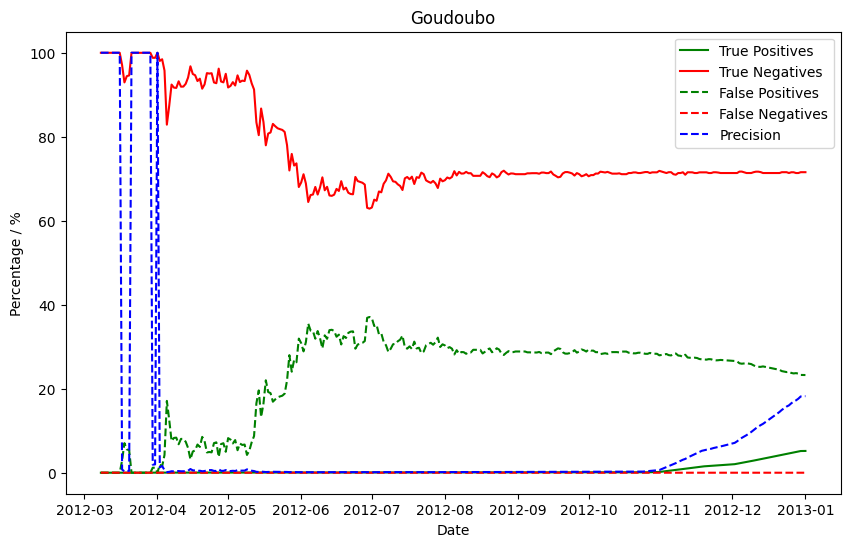

43.88952455630482
Mean precision is 43.88952455630482


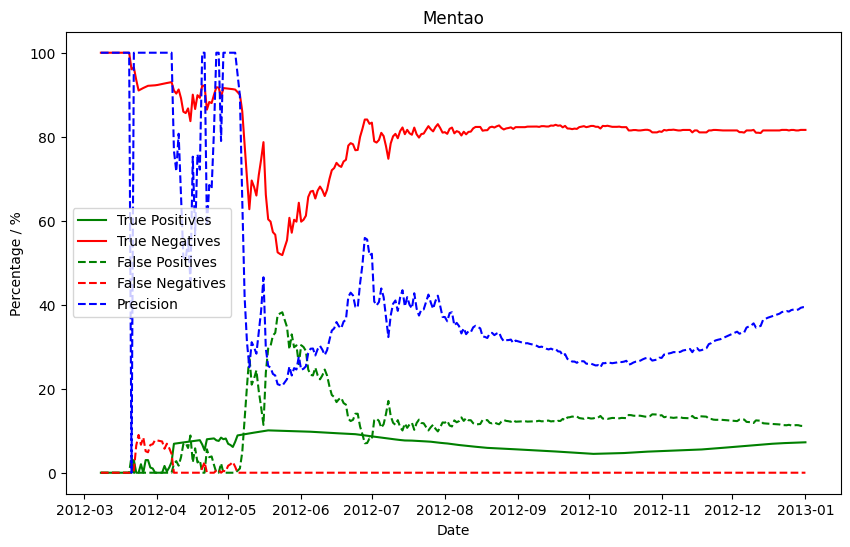

68.90182075136727
Mean precision is 68.90182075136727


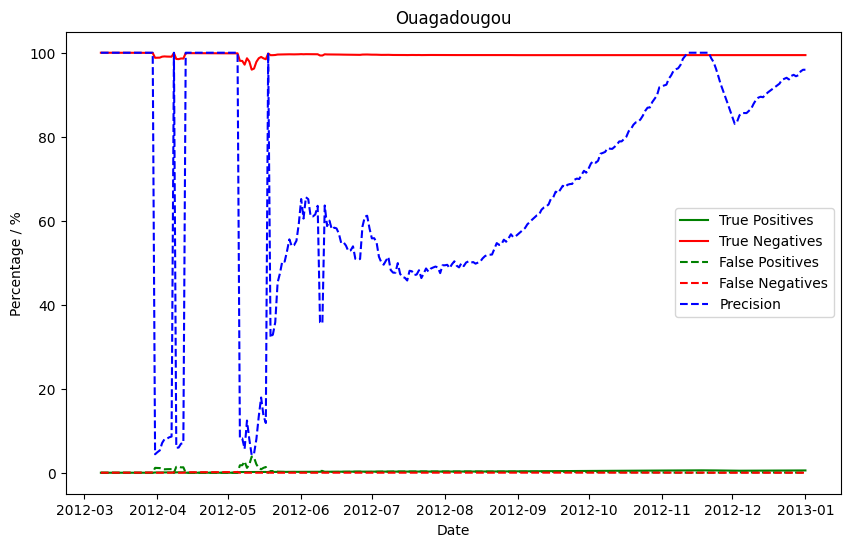

91.69024202585689
Mean precision is 91.69024202585689


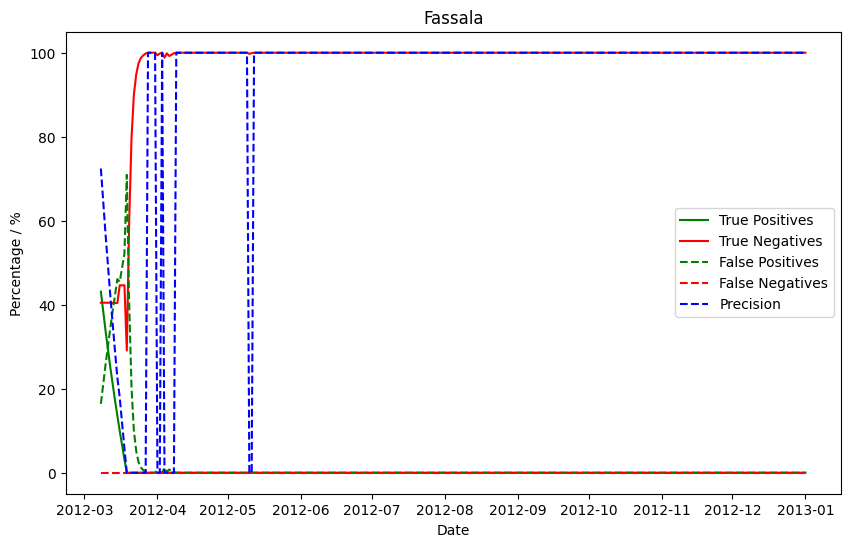

99.87110060736961
Mean precision is 99.87110060736961


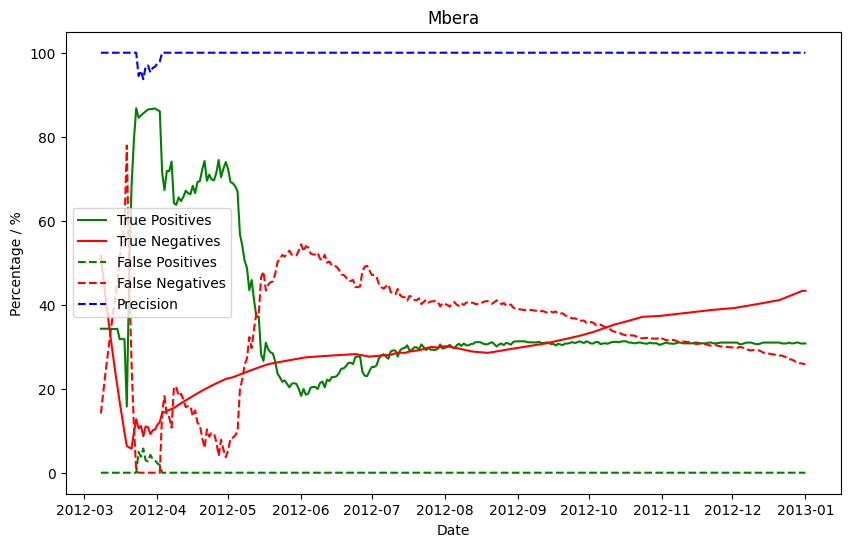

96.27609809105644
Mean precision is 96.27609809105644


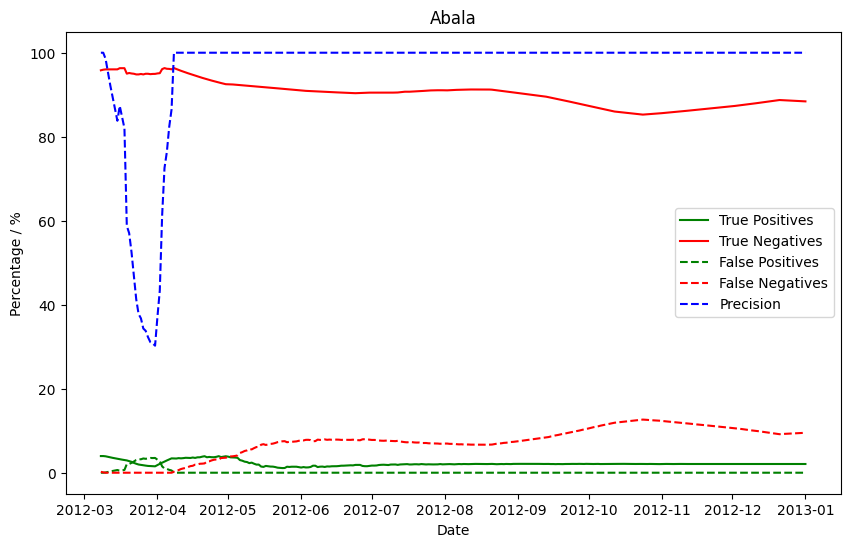

48.54348131484328
Mean precision is 48.54348131484328


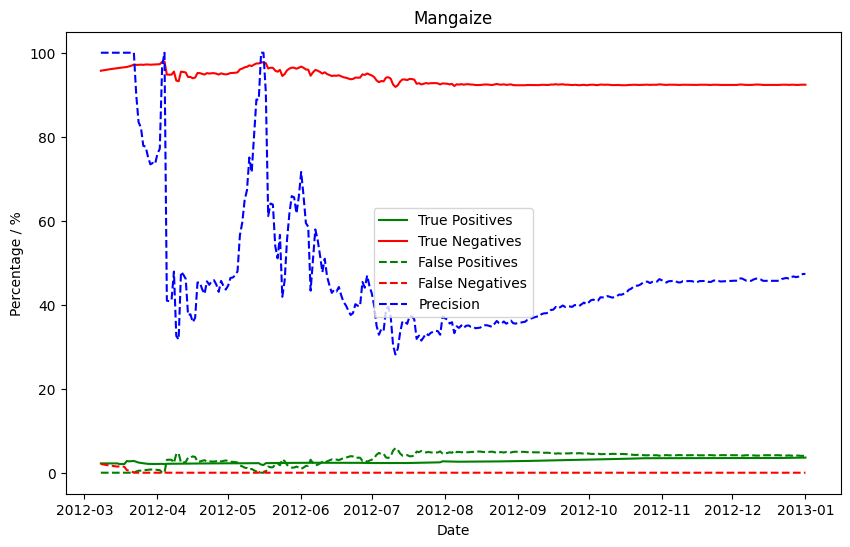

93.73278167861822
Mean precision is 93.73278167861822


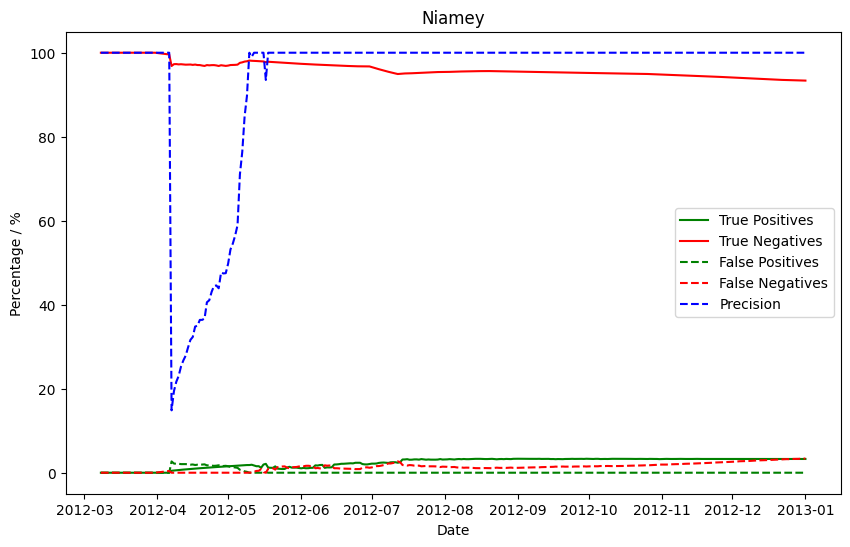

76.49793886371653
Mean precision is 76.49793886371653


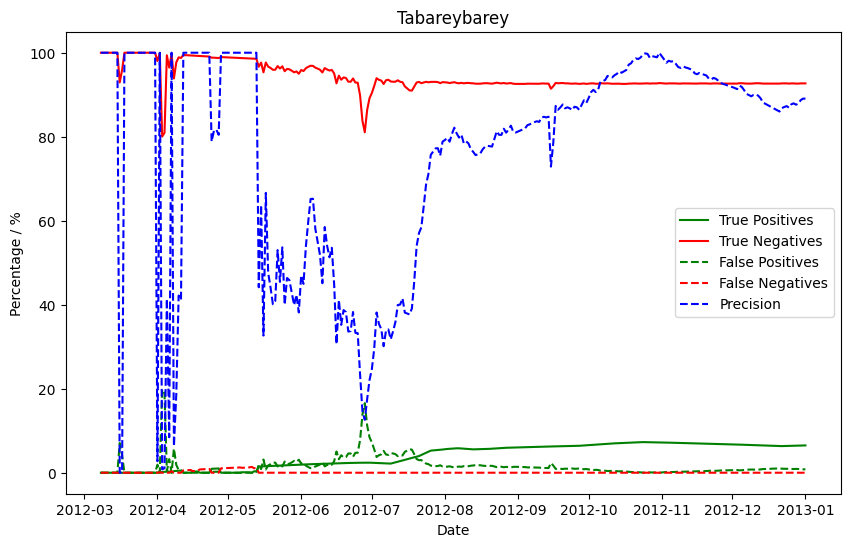

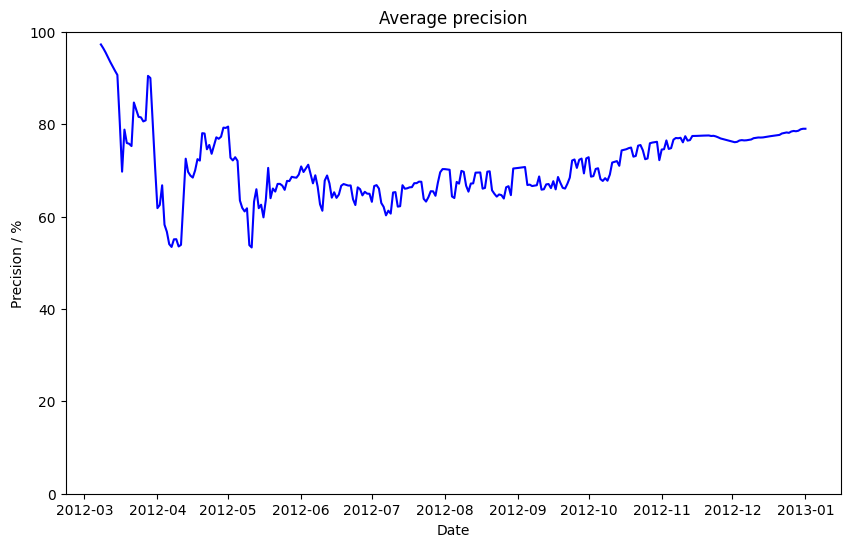

In [83]:
# CAMP DISTRIBUTION
emps = [
    bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'][67:].values,
    goudoubo['Nombre estimé de réfugiés maliens par période'][67:].values,
    mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'][67:].values,
    ouagadougou['Nombre estimé de réfugiés maliens par période'][67:].values,
    fassala['Réfugiés maliens'][67:].values,
    mbera['Réfugiés maliens'][67:].values,
    abala['Nombre estimé de réfugiés maliens par période'][67:].values,
    mangaize['Nombre estimé de réfugiés maliens par période'][67:].values,
    niamey['Nombre estimé de réfugiés maliens par période'][67:].values,
    tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'][67:].values
]

empsum = [sum(values) for values in zip(*emps)]
print(len(empsum))

empnorms = []
for inner_list in emps:
    normalized_list = [value / empsum[o] if empsum[o] != 0 else 0 for o, value in enumerate(inner_list)]
    empnorms.append(normalized_list)
print("empnorms:", empnorms)

sims = [
    bobo_sim[67:].values, goudoubo_sim[67:].values, mentao_sim[67:].values, ouagadougou_sim[67:].values,
    fassala_sim[67:].values, mbera_sim[67:].values, abala_sim[67:].values, mangaize_sim[67:].values, 
    niamey_sim[67:].values, tabareybarey_sim[67:].values
]

simsum = [sum(values) for values in zip(*sims)]
print(simsum)

simnorms = []
for inner_list in sims:
    normalized_list = [value / simsum[i] if simsum[i] != 0 else 0 for i, value in enumerate(inner_list)]
    simnorms.append(normalized_list)
print("simnorms:", simnorms)

# Initialize arrays separately for each location
acc_dic = {
    'Bobo': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Goudoubo': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Mentao': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Ouagadougou': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Fassala': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Mbera': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Abala': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Mangaize': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Niamey': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))},
    'Tabareybarey': {'fns': np.zeros(len(empsum)), 'tns': np.zeros(len(empsum)), 'fps': np.zeros(len(empsum)), 'tps': np.zeros(len(empsum))}
}

labels = ['Bobo','Goudoubo','Mentao','Ouagadougou',
          'Fassala','Mbera','Abala','Mangaize',
          'Niamey', 'Tabareybarey']

for i in range(len(emps)):
    for j in range(len(empsum)):
        print(len(simnorms[i]))
        acc_dic[labels[i]]['tps'][j] = min(empnorms[i][j], simnorms[i][j])
        if empnorms[i][j] > simnorms[i][j]:
            acc_dic[labels[i]]['fns'][j] = empnorms[i][j] - simnorms[i][j]
            acc_dic[labels[i]]['tns'][j] = 1 - empnorms[i][j]
        else:
            acc_dic[labels[i]]['fps'][j] = simnorms[i][j] - empnorms[i][j]
            acc_dic[labels[i]]['tns'][j] = 1 - simnorms[i][j]


for camp in labels:
    # Create a new figure
    tps = np.array(acc_dic[camp]['tps'])
    fps = np.array(acc_dic[camp]['fps'])
    denominator = tps + fps
    acc_dic[camp]['Precision'] = np.where(denominator != 0, tps / denominator, 1)

    plt.figure(figsize=(10, 6))

    # Plotting the data
    print(np.mean(100*acc_dic[camp]['Precision']))
    plt.plot(date_sim[67:], 100*acc_dic[camp]['tps'], color='g', label='True Positives')
    plt.plot(date_sim[67:], 100*acc_dic[camp]['tns'], color='r', label='True Negatives')
    plt.plot(date_sim[67:], 100*acc_dic[camp]['fps'], color='g', linestyle='--', label='False Positives')
    plt.plot(date_sim[67:], 100*acc_dic[camp]['fns'], color='r', linestyle='--', label='False Negatives')
    plt.plot(date_sim[67:], 100*acc_dic[camp]['Precision'], color='b',linestyle='--',label='Precision')
    
    print("Mean precision is " + str(np.mean(100*acc_dic[camp]['Precision'])))
    
    # Adding titles and labels
    plt.title(camp)
    plt.xlabel('Date')
    plt.ylabel('Percentage / %')

    # Adding a legend
    plt.legend()

    # Show the plot
    plt.show()


precisionsum = [0] * len(next(iter(acc_dic.values()))['Precision'])

# Loop through the dictionary of dictionaries
for val, dic in acc_dic.items():
    i = 0
    for accval in dic['Precision']:
        precisionsum[i] += accval
        i += 1

prec= [100*x/len(emps) for x in precisionsum]

plt.figure(figsize=(10, 6))
plt.plot(date_sim[67:],prec, color='b')
plt.title('Average precision')
plt.xlabel('Date')
plt.ylabel('Precision / %')
plt.ylim(0,100)
plt.show()









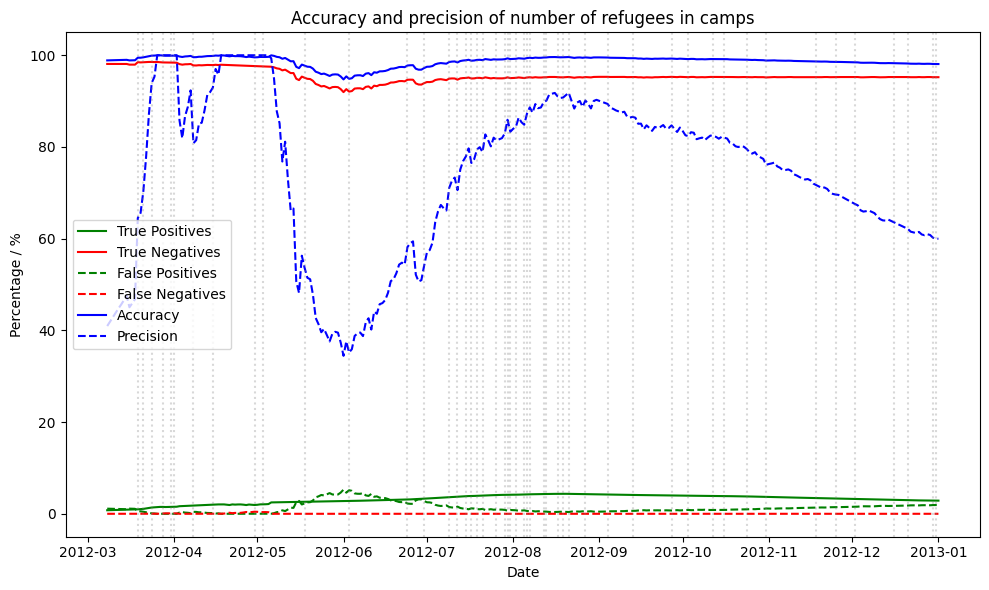

Empirical-only Accuracy:  98.99%
Empirical-only Precision: 79.56%


In [84]:
# Number of refugees in camps

tps = np.zeros(len(empsum))
fps = np.zeros(len(empsum))
tns = np.zeros(len(empsum))
fns = np.zeros(len(empsum))
prec = np.zeros(len(empsum))
acc = np.zeros(len(empsum))
totsum = 3321680 * np.ones(len(empsum))

# 1. Calculate for ALL points (empsum has length 300)
for i in range(len(empsum)):
    tps[i] = min(empsum[i], simsum[i]) / totsum[i]
    if empsum[i] > simsum[i]:
        fns[i] = (empsum[i] - simsum[i]) / totsum[i]
        tns[i] = (3321680 - empsum[i]) / totsum[i]
        fps[i] = 0.0
    else:
        fps[i] = (simsum[i] - empsum[i]) / totsum[i]
        tns[i] = (3321680 - simsum[i]) / totsum[i]
        fns[i] = 0.0
        
    total_pred_pos = tps[i] + fps[i]
    prec[i] = 1.0 if total_pred_pos == 0 else tps[i] / total_pred_pos
    acc[i] = (tps[i] + tns[i]) / (tps[i] + fps[i] + tns[i] + fns[i])

# 2. Plotting (date_sim[67:] drops from 367 to 300, perfectly matching your metrics!)
plt.figure(figsize=(10, 6))
plt.plot(date_sim[67:], 100*tps, color='g', label='True Positives')
plt.plot(date_sim[67:], 100*tns, color='r', label='True Negatives')
plt.plot(date_sim[67:], 100*fps, color='g', linestyle='--', label='False Positives')
plt.plot(date_sim[67:], 100*fns, color='r', linestyle='--', label='False Negatives')
plt.plot(date_sim[67:], 100*acc, color='b', label='Accuracy')
plt.plot(date_sim[67:], 100*prec, color='b', linestyle='--', label='Precision')

# Optional visual aid: Add light vertical lines for empirical data points
# is_real_total needs to be sliced to 300 elements if it was originally 367
is_real_sliced = is_real_total[67:] if len(is_real_total) == 367 else is_real_total
for d in date_sim[67:][is_real_sliced]:
    plt.axvline(x=d, color='gray', linestyle=':', alpha=0.3)

plt.title('Accuracy and precision of number of refugees in camps')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Percentage / %')
plt.tight_layout()
plt.show()

# 3. Print values calculated STRICTLY on real empirical points
print(f"Empirical-only Accuracy:  {np.mean(100 * acc[is_real_sliced]):.2f}%")
print(f"Empirical-only Precision: {np.mean(100 * prec[is_real_sliced]):.2f}%")

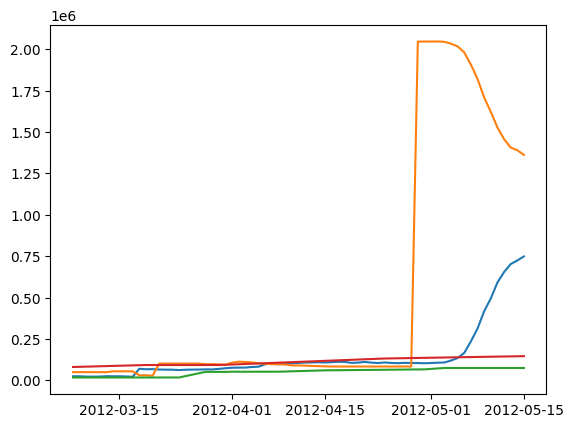

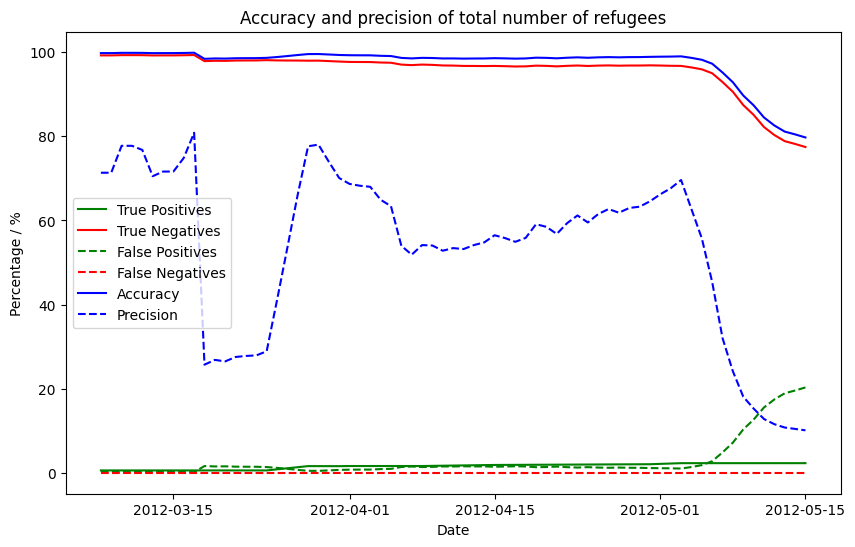

--- Total Refugees Empirical Metrics ---
Empirical-only Accuracy:  98.84%
Empirical-only Precision: 52.78%



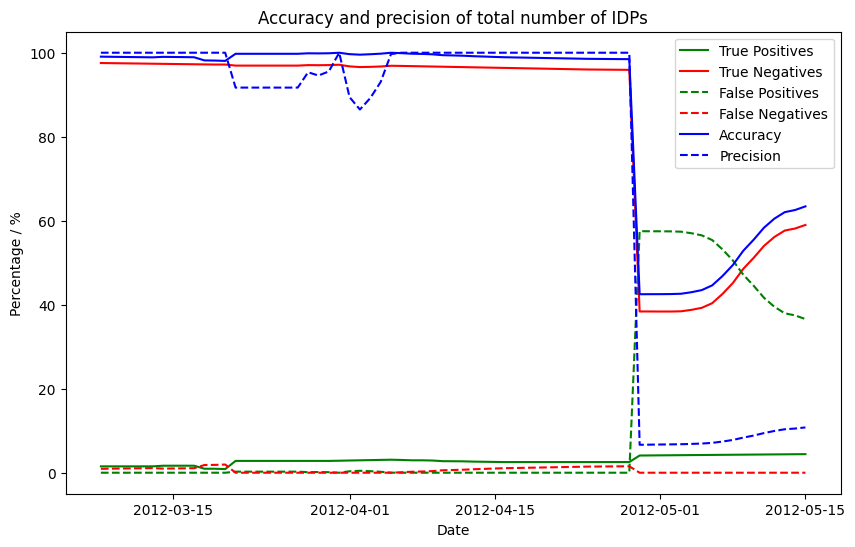

--- Total IDPs Empirical Metrics ---
Empirical-only Accuracy:  87.95%
Empirical-only Precision: 79.23%


In [85]:
# Number of Refugees

def prepare_data(df, date_col, value_col, date_range):
    df[date_col] = pd.to_datetime(df[date_col], format='%Y-%m-%d')
    df.set_index(date_col, inplace=True)

    # Interpolating missing dates
    df = df.reindex(date_range).interpolate(method='time')

    # Extrapolating the first and last values if necessary
    df = df.ffill().bfill()

    return df

def prepare_data2(df, date_col, value_col, date_range):
    df[date_col] = pd.to_datetime(df[date_col], format='%d-%m-%Y')
    df.set_index(date_col, inplace=True)

    # Interpolating missing dates
    df = df.reindex(date_range).interpolate(method='time')

    # Extrapolating the first and last values if necessary
    df = df.ffill().bfill()

    return df

df = pd.read_csv('pop_data/source-data-unhcr-pdf-reports.csv')

# Define the empirical mask matching your simulation slice window (68 to 137)
real_mask_sliced = is_real_total[68:137]

date_range = pd.date_range(start='2012-03-08', end='2012-05-15')
ref_df = pd.read_csv('pop_data/refugees.csv')
date_col='DateTime'
value_col='Réfugiés maliens'
date_col2='date'
value_col2='Internally Displaced'

ref_df = prepare_data(ref_df, date_col, value_col, date_range)
idp = prepare_data2(df, date_col2, value_col2, date_range)

ref_sim2=ref_sim[68:137]
idp_sim2=idp_sim[68:137]

plt.figure()
plt.plot(date_range,ref_sim2)
plt.plot(date_range,idp_sim2)
plt.plot(date_range,ref_df[value_col])
plt.plot(date_range,idp[value_col2])

totsum=3321680*np.ones(len(ref_sim2))
tps = np.zeros(len(ref_sim2))
fps = np.zeros(len(ref_sim2))
tns = np.zeros(len(ref_sim2))
fns = np.zeros(len(ref_sim2))
prec = np.zeros(len(ref_sim2))
acc = np.zeros(len(ref_sim2))

refsim=[x for x in ref_sim2]
refemp=[x for x in ref_df[value_col]]


# ============================================================
# REFUGEES EVALUATION
# ============================================================
for i in range(len(ref_sim2)):
    tps[i] = min(refemp[i], refsim[i]) / totsum[i]
    if refemp[i] > refsim[i]:
        fns[i] = (refemp[i] - refsim[i]) / totsum[i]
        tns[i] = (3321680 - refemp[i]) / totsum[i]
        fps[i] = 0.0
    else:
        fps[i] = (refsim[i] - refemp[i]) / totsum[i]
        tns[i] = (3321680 - refsim[i]) / totsum[i]
        fns[i] = 0.0
    prec[i] = tps[i] / (tps[i] + fps[i]) if (tps[i] + fps[i]) != 0 else 1
    acc[i] = (tps[i] + tns[i]) / (tps[i] + fps[i] + tns[i] + fns[i]) if (tps[i] + fps[i] + tns[i] + fns[i]) != 0 else 1


plt.figure(figsize=(10, 6))
plt.plot(date_range, 100*tps, color='g', label='True Positives')
plt.plot(date_range, 100*tns, color='r', label='True Negatives')
plt.plot(date_range, 100*fps, color='g', linestyle='--', label='False Positives')
plt.plot(date_range, 100*fns, color='r', linestyle='--', label='False Negatives')
plt.plot(date_range, 100*acc, color='b',label='Accuracy')
plt.plot(date_range, 100*prec, color='b',linestyle='--',label='Precision')
plt.title('Accuracy and precision of total number of refugees')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Percentage / %')
plt.show()

print("--- Total Refugees Empirical Metrics ---")
print(f"Empirical-only Accuracy:  {np.mean(100 * acc[real_mask_sliced]):.2f}%")
print(f"Empirical-only Precision: {np.mean(100 * prec[real_mask_sliced]):.2f}%\n")

# ============================================================
# IDPS EVALUATION
# ============================================================
idpsim=[x for x in idp_sim2]
idpemp=[x for x in idp[value_col2]]

for i in range(len(idp_sim2)):
    tps[i] = min(idpemp[i], idpsim[i]) / totsum[i]
    if idpemp[i] > idpsim[i]:
        fns[i] = (idpemp[i] - idpsim[i]) / totsum[i]
        tns[i] = (3321680 - idpemp[i]) / totsum[i]
        fps[i] = 0.0
    else:
        fps[i] = (idpsim[i] - idpemp[i]) / totsum[i]
        tns[i] = (3321680 - idpsim[i]) / totsum[i]
        fns[i] = 0.0
    prec[i] = tps[i] / (tps[i] + fps[i]) if (tps[i] + fps[i]) != 0 else 1
    acc[i] = (tps[i] + tns[i]) / (tps[i] + fps[i] + tns[i] + fns[i]) if (tps[i] + fps[i] + tns[i] + fns[i]) != 0 else 1


plt.figure(figsize=(10, 6))
plt.plot(date_range, 100*tps, color='g', label='True Positives')
plt.plot(date_range, 100*tns, color='r', label='True Negatives')
plt.plot(date_range, 100*fps, color='g', linestyle='--', label='False Positives')
plt.plot(date_range, 100*fns, color='r', linestyle='--', label='False Negatives')
plt.plot(date_range, 100*acc, color='b',label='Accuracy')
plt.plot(date_range, 100*prec, color='b',linestyle='--',label='Precision')
plt.title('Accuracy and precision of total number of IDPs')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Percentage / %')
plt.show()

print("--- Total IDPs Empirical Metrics ---")
print(f"Empirical-only Accuracy:  {np.mean(100 * acc[real_mask_sliced]):.2f}%")
print(f"Empirical-only Precision: {np.mean(100 * prec[real_mask_sliced]):.2f}%")

In [86]:
# ============================================================
# ADDITIONAL CELL:
# LOAD ABLATION RUNS (NO ROULETTE / NO GROUPING / NO COMM)
# ============================================================

# Expected filenames:
# "No roulette/Camp_splits.csv"
# "No grouping/Camp_splits.csv"
# "No communication/Camp_splits.csv"

# Adjust paths if your folders differ.

# ---------- NO ROULETTE ----------
sim_nr = pd.read_csv("no_roulette/Camp_splits.csv")

date_nr = pd.to_datetime(sim_nr['Date'])

bobo_nr = sim_nr['Bobo']
goudoubo_nr = sim_nr['Goudoubo']
mentao_nr = sim_nr['Mentao']
ouagadougou_nr = sim_nr['Ouagadougou']
fassala_nr = sim_nr['Fassala']
mbera_nr = sim_nr['Mbera']
abala_nr = sim_nr['Abala']
mangaize_nr = sim_nr['Mangaize']
niamey_nr = sim_nr['Niamey']
tabareybarey_nr = sim_nr['Tabareybarey']


# ---------- NO GROUPING ----------
sim_ng = pd.read_csv("no_group/Camp_splits.csv")

date_ng = pd.to_datetime(sim_ng['Date'])

bobo_ng = sim_ng['Bobo']
goudoubo_ng = sim_ng['Goudoubo']
mentao_ng = sim_ng['Mentao']
ouagadougou_ng = sim_ng['Ouagadougou']
fassala_ng = sim_ng['Fassala']
mbera_ng = sim_ng['Mbera']
abala_ng = sim_ng['Abala']
mangaize_ng = sim_ng['Mangaize']
niamey_ng = sim_ng['Niamey']
tabareybarey_ng = sim_ng['Tabareybarey']


# ---------- NO COMMUNICATION ----------
sim_nc = pd.read_csv("no_comm/Camp_splits.csv")

date_nc = pd.to_datetime(sim_nc['Date'])

bobo_nc = sim_nc['Bobo']
goudoubo_nc = sim_nc['Goudoubo']
mentao_nc = sim_nc['Mentao']
ouagadougou_nc = sim_nc['Ouagadougou']
fassala_nc = sim_nc['Fassala']
mbera_nc = sim_nc['Mbera']
abala_nc = sim_nc['Abala']
mangaize_nc = sim_nc['Mangaize']
niamey_nc = sim_nc['Niamey']
tabareybarey_nc = sim_nc['Tabareybarey']

print("Ablation runs loaded successfully.")

Ablation runs loaded successfully.


In [87]:
# ============================================================
# ADDITIONAL CELL:
# ONLY USE REAL OBSERVATION DATES (NO INTERPOLATED POINTS)
# ============================================================

# Build masks for real observation dates only

camp_data = {
    'Bobo': (
        bobo,
        'Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'
    ),
    'Goudoubo': (
        goudoubo,
        'Nombre estimé de réfugiés maliens par période'
    ),
    'Mentao': (
        mentao,
        'Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'
    ),
    'Ouagadougou': (
        ouagadougou,
        'Nombre estimé de réfugiés maliens par période'
    ),
    'Fassala': (
        fassala,
        'Réfugiés maliens'
    ),
    'Mbera': (
        mbera,
        'Réfugiés maliens'
    ),
    'Abala': (
        abala,
        'Nombre estimé de réfugiés maliens par période'
    ),
    'Mangaize': (
        mangaize,
        'Nombre estimé de réfugiés maliens par période'
    ),
    'Niamey': (
        niamey,
        'Nombre estimé de réfugiés maliens par période'
    ),
    'Tabareybarey': (
        tabareybarey,
        'Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'
    )
}

print("Camp dictionary created.")

Camp dictionary created.


/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/1213345313.py:90: RuntimeWarning: invalid value encountered in divide
  relative_diff = np.abs(emp_values - sim_values) / emp_values
/var/folders/s9/s5q4rpnj00j_kr4yj0f8c_dm0000gp/T/ipykernel_4197/1213345313.py:90: RuntimeWarning: divide by zero encountered in divide
  relative_diff = np.abs(emp_values - sim_values) / emp_values


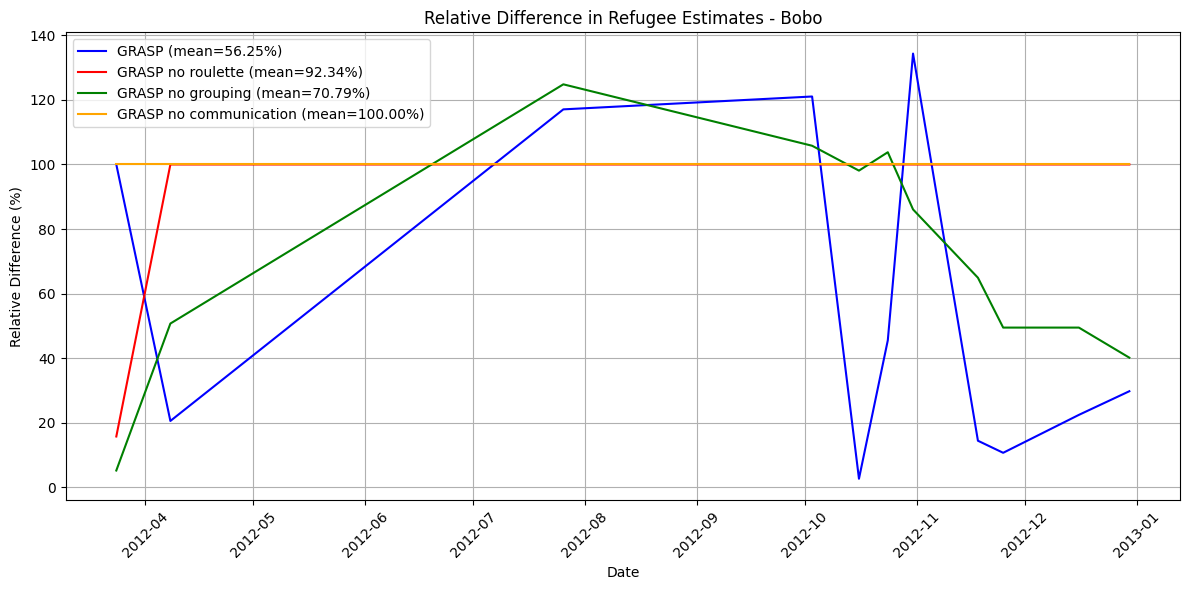

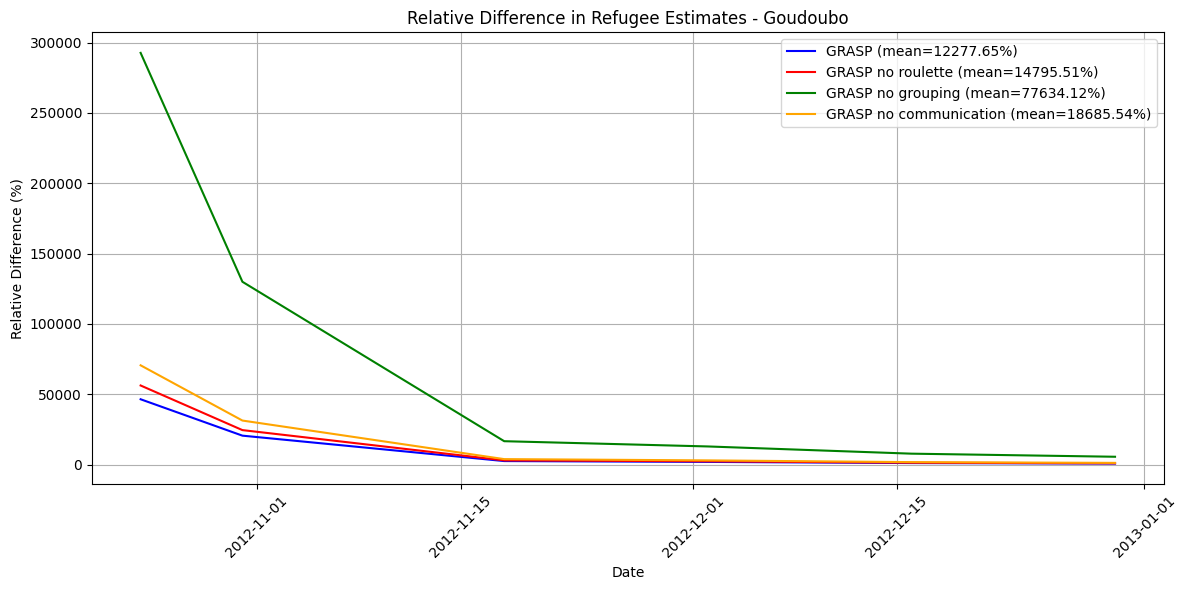

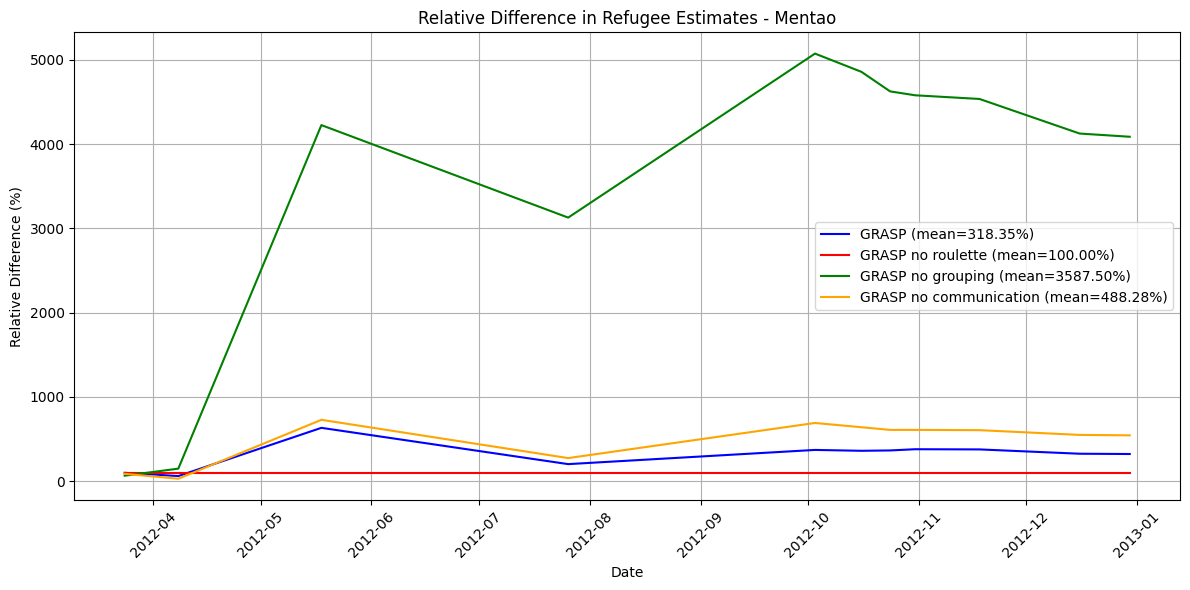

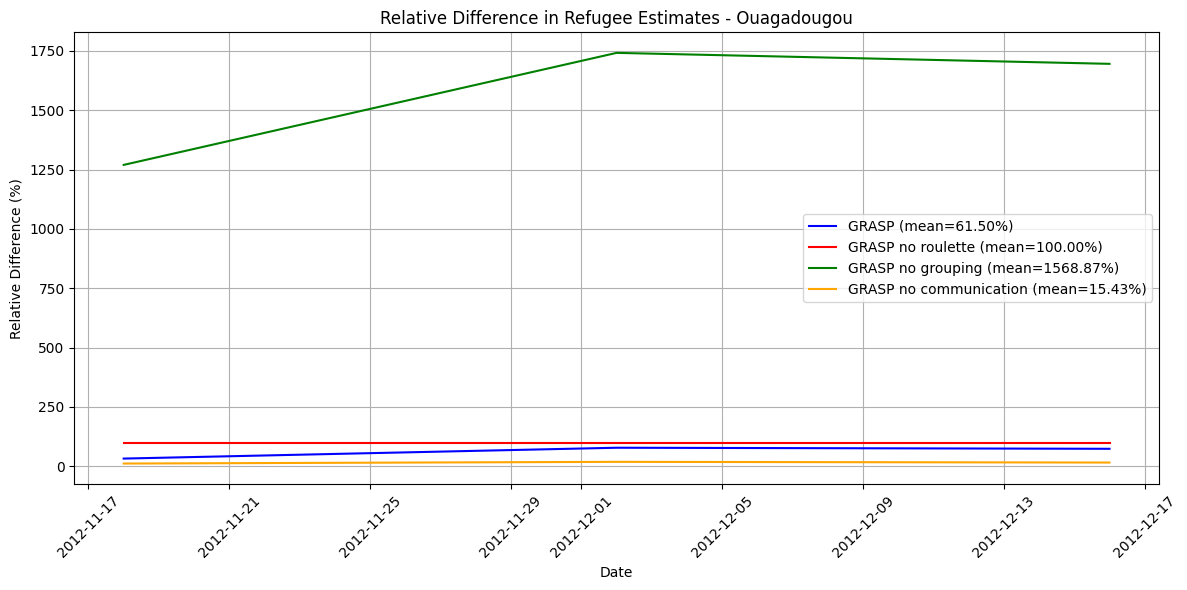

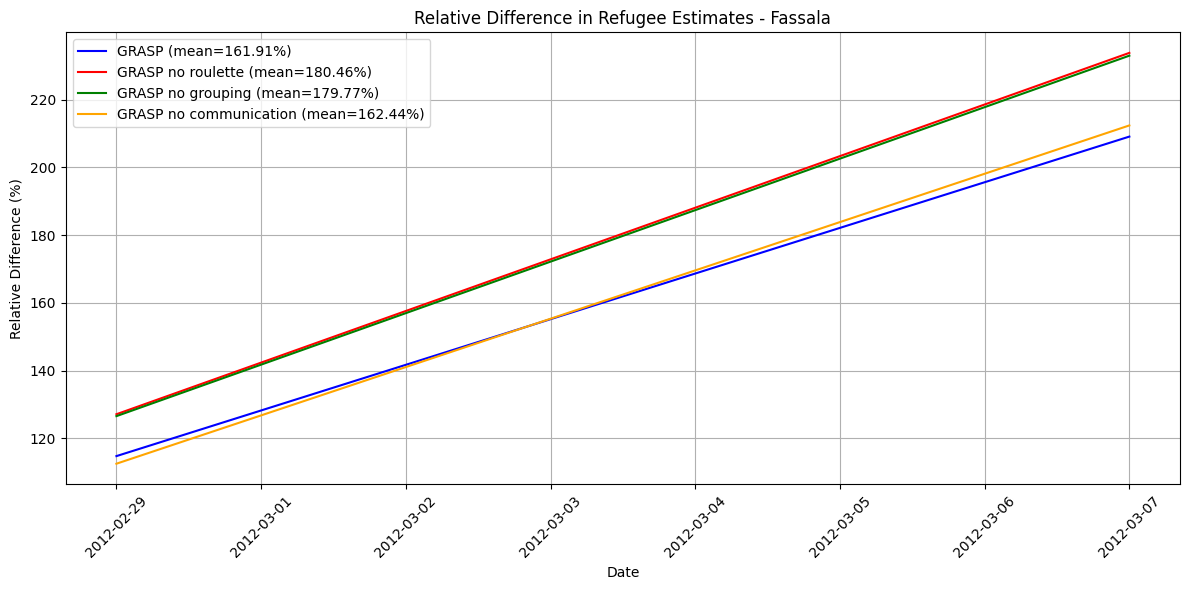

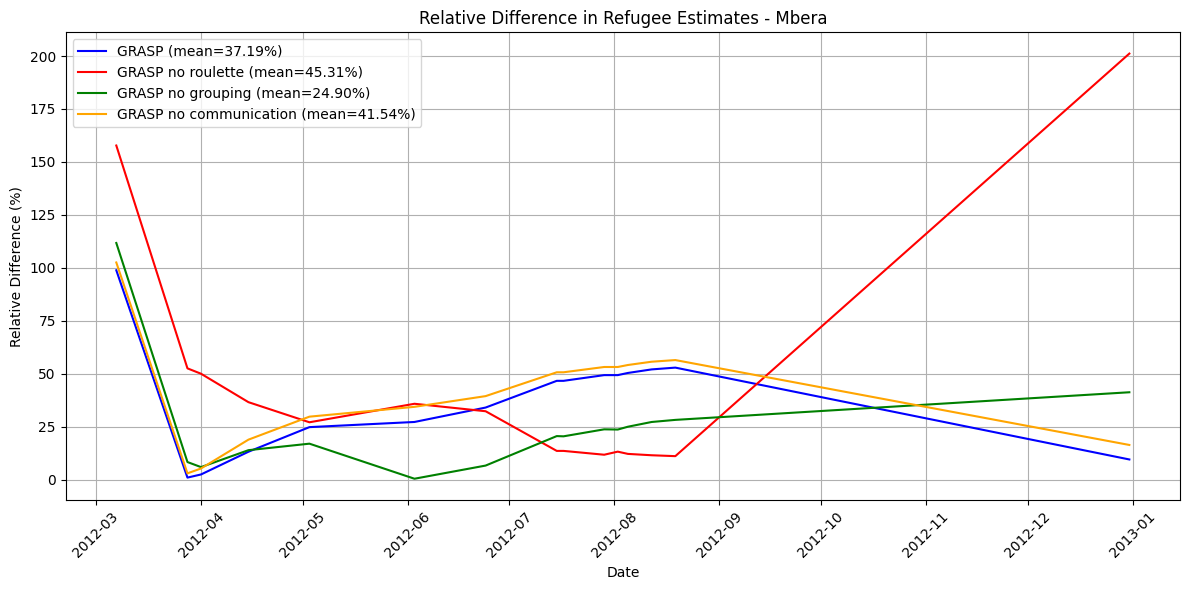

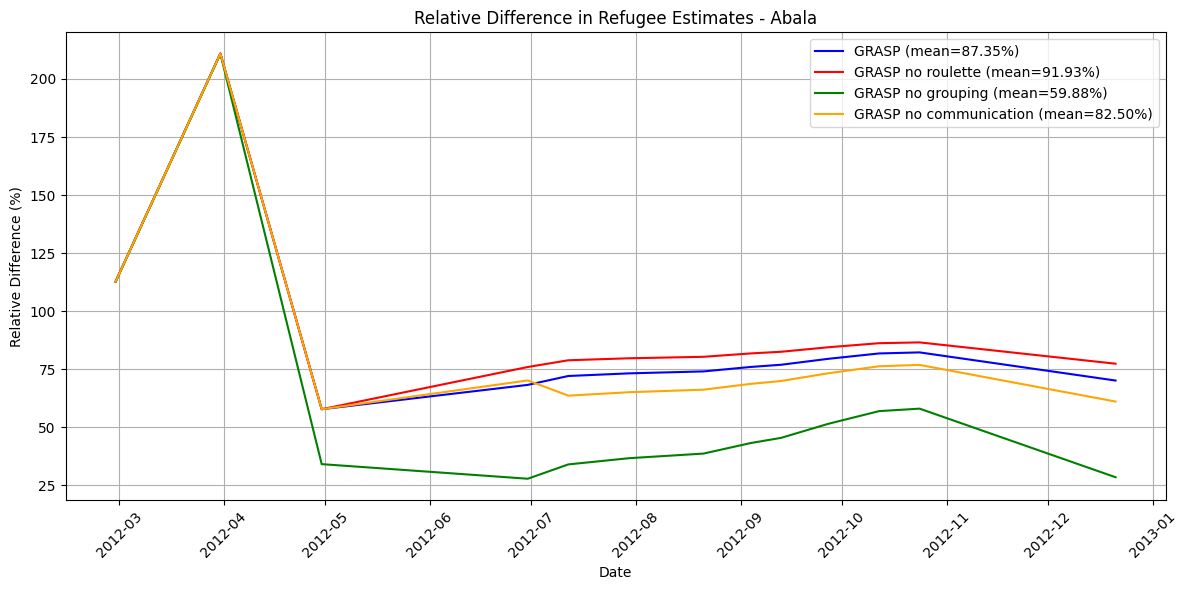

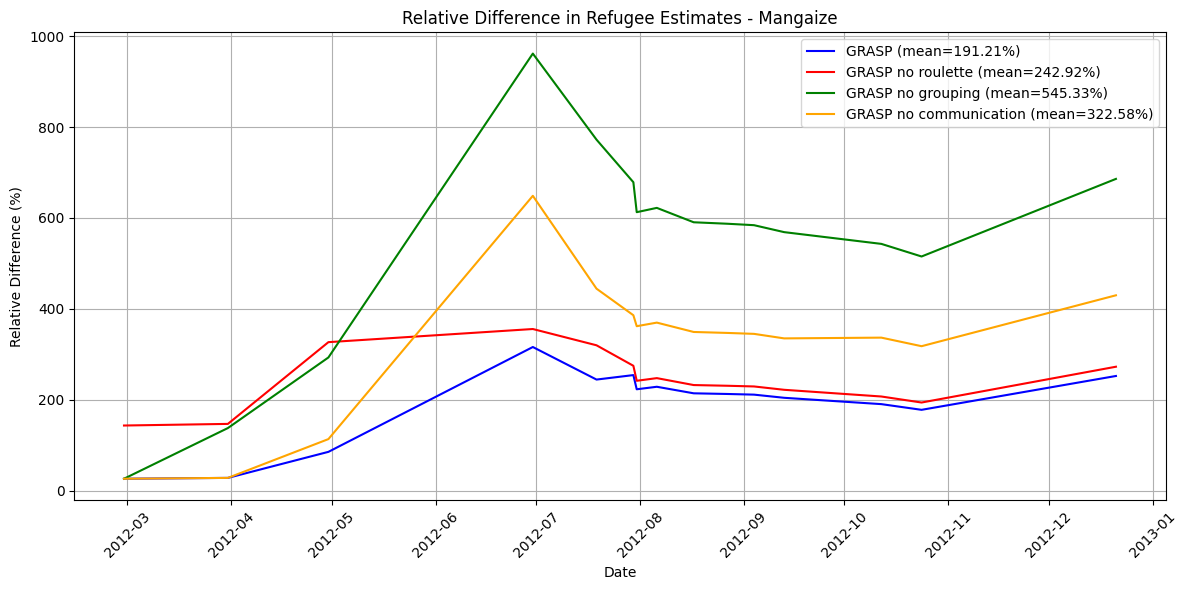

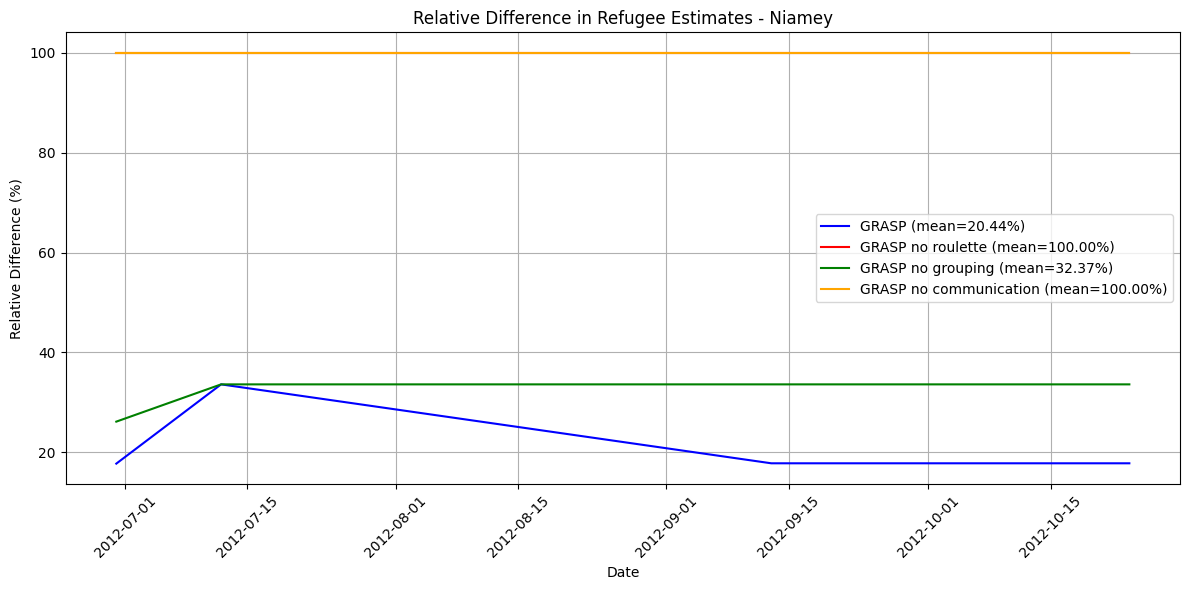

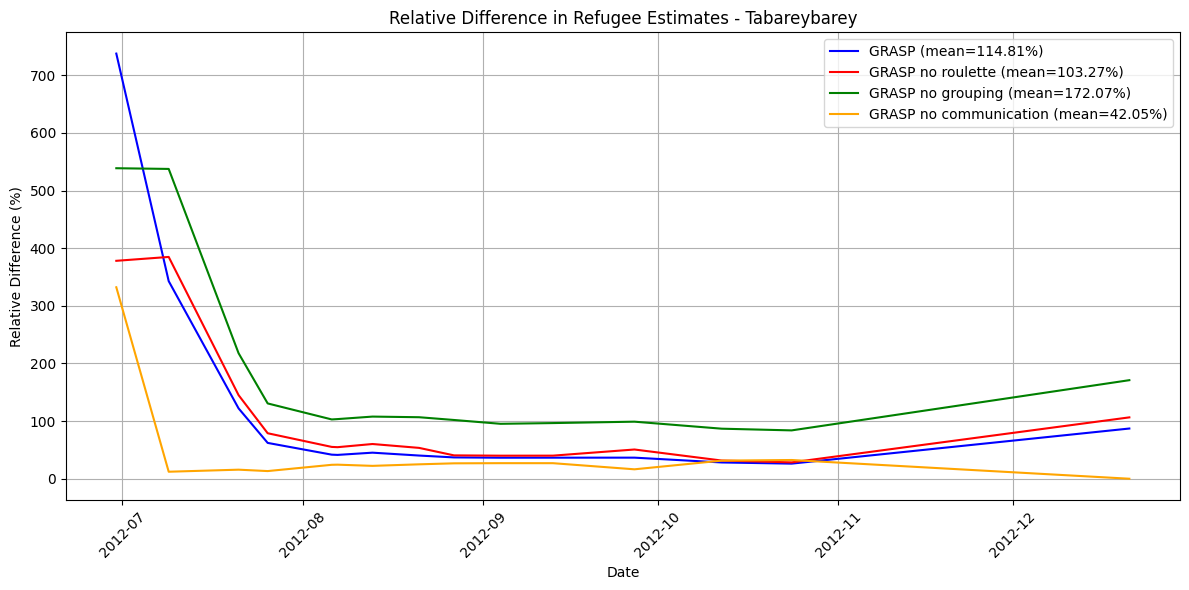

In [88]:
# ============================================================
# ADDITIONAL CELL:
# RELATIVE DIFFERENCE PLOTS FOR ALL METHODS
# (ONLY REAL OBSERVATION DATES)
# ============================================================

# Simulation dictionaries
sim_dicts = {
    'GRASP': {
        'Bobo': bobo_sim,
        'Goudoubo': goudoubo_sim,
        'Mentao': mentao_sim,
        'Ouagadougou': ouagadougou_sim,
        'Fassala': fassala_sim,
        'Mbera': mbera_sim,
        'Abala': abala_sim,
        'Mangaize': mangaize_sim,
        'Niamey': niamey_sim,
        'Tabareybarey': tabareybarey_sim
    },

    'GRASP no roulette': {
        'Bobo': bobo_nr,
        'Goudoubo': goudoubo_nr,
        'Mentao': mentao_nr,
        'Ouagadougou': ouagadougou_nr,
        'Fassala': fassala_nr,
        'Mbera': mbera_nr,
        'Abala': abala_nr,
        'Mangaize': mangaize_nr,
        'Niamey': niamey_nr,
        'Tabareybarey': tabareybarey_nr
    },

    'GRASP no grouping': {
        'Bobo': bobo_ng,
        'Goudoubo': goudoubo_ng,
        'Mentao': mentao_ng,
        'Ouagadougou': ouagadougou_ng,
        'Fassala': fassala_ng,
        'Mbera': mbera_ng,
        'Abala': abala_ng,
        'Mangaize': mangaize_ng,
        'Niamey': niamey_ng,
        'Tabareybarey': tabareybarey_ng
    },

    'GRASP no communication': {
        'Bobo': bobo_nc,
        'Goudoubo': goudoubo_nc,
        'Mentao': mentao_nc,
        'Ouagadougou': ouagadougou_nc,
        'Fassala': fassala_nc,
        'Mbera': mbera_nc,
        'Abala': abala_nc,
        'Mangaize': mangaize_nc,
        'Niamey': niamey_nc,
        'Tabareybarey': tabareybarey_nc
    }
}

colors = {
    'GRASP': 'blue',
    'GRASP no roulette': 'red',
    'GRASP no grouping': 'green',
    'GRASP no communication': 'orange'
}

# Store mean relative errors
mean_relative_errors = {}

for camp in camp_data.keys():

    df_emp, col = camp_data[camp]

    # ONLY REAL OBSERVATIONS
    real_mask = df_emp['is_real']

    emp_values = df_emp.loc[real_mask, col].values
    real_dates = date_sim[real_mask.values]

    plt.figure(figsize=(12, 6))

    mean_relative_errors[camp] = {}

    for sim_name, sim_dic in sim_dicts.items():

        sim_values = np.array(sim_dic[camp])[real_mask.values.astype(bool)]

        relative_diff = np.abs(emp_values - sim_values) / emp_values
        relative_diff = np.where(np.isfinite(relative_diff), relative_diff, np.nan)

        mean_err = np.nanmean(relative_diff)

        mean_relative_errors[camp][sim_name] = mean_err

        plt.plot(
            real_dates,
            100 * relative_diff,
            label=f"{sim_name} (mean={100*mean_err:.2f}%)",
            color=colors[sim_name]
        )

    plt.title(f"Relative Difference in Refugee Estimates - {camp}")
    plt.xlabel("Date")
    plt.ylabel("Relative Difference (%)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

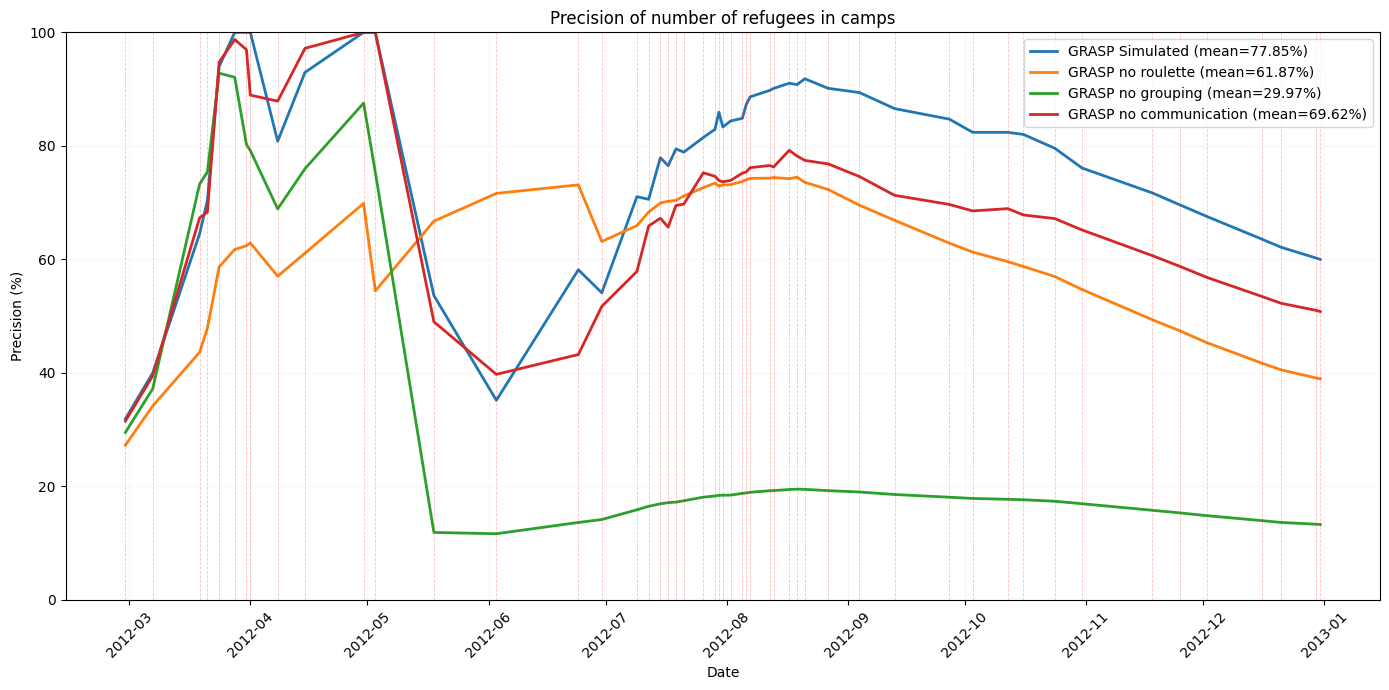

In [90]:
# ============================================================
# PRECISION CALCULATION (OBSERVED DATES ONLY)
# ============================================================

TOTAL_POP = 3321680

precision_results = {}

# empirical camps
emp_camps = [
    bobo['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'].values,
    goudoubo['Nombre estimé de réfugiés maliens par période'].values,
    mentao['Nombre estimé de réfugiés maliens par période (border opens on 21st of March)'].values,
    ouagadougou['Nombre estimé de réfugiés maliens par période'].values,
    fassala['Réfugiés maliens'].values,
    mbera['Réfugiés maliens'].values,
    abala['Nombre estimé de réfugiés maliens par période'].values,
    mangaize['Nombre estimé de réfugiés maliens par période'].values,
    niamey['Nombre estimé de réfugiés maliens par période'].values,
    tabareybarey['Nombre estimé de réfugiés maliens par période (border opens 21st of March 2012)'].values
]

emp_sum = np.sum(emp_camps, axis=0)

# ------------------------------------------------------------------
# Only evaluate on dates with genuine observations
# ------------------------------------------------------------------
is_real_total = (
    bobo['is_real'].values |
    goudoubo['is_real'].values |
    mentao['is_real'].values |
    ouagadougou['is_real'].values |
    fassala['is_real'].values |
    mbera['is_real'].values |
    abala['is_real'].values |
    mangaize['is_real'].values |
    niamey['is_real'].values |
    tabareybarey['is_real'].values
)

method_sims = {
    'GRASP Simulated': [
        bobo_sim.values,
        goudoubo_sim.values,
        mentao_sim.values,
        ouagadougou_sim.values,
        fassala_sim.values,
        mbera_sim.values,
        abala_sim.values,
        mangaize_sim.values,
        niamey_sim.values,
        tabareybarey_sim.values
    ],

    'GRASP no roulette': [
        bobo_nr.values,
        goudoubo_nr.values,
        mentao_nr.values,
        ouagadougou_nr.values,
        fassala_nr.values,
        mbera_nr.values,
        abala_nr.values,
        mangaize_nr.values,
        niamey_nr.values,
        tabareybarey_nr.values
    ],

    'GRASP no grouping': [
        bobo_ng.values,
        goudoubo_ng.values,
        mentao_ng.values,
        ouagadougou_ng.values,
        fassala_ng.values,
        mbera_ng.values,
        abala_ng.values,
        mangaize_ng.values,
        niamey_ng.values,
        tabareybarey_ng.values
    ],

    'GRASP no communication': [
        bobo_nc.values,
        goudoubo_nc.values,
        mentao_nc.values,
        ouagadougou_nc.values,
        fassala_nc.values,
        mbera_nc.values,
        abala_nc.values,
        mangaize_nc.values,
        niamey_nc.values,
        tabareybarey_nc.values
    ]
}
plt.figure(figsize=(14, 7))

for method_name, sim_camps in method_sims.items():

    sim_sum = np.sum(sim_camps, axis=0)

    precision = np.full(len(emp_sum), np.nan)

    for i in np.where(is_real_total)[0]:

        tp = min(emp_sum[i], sim_sum[i]) / TOTAL_POP

        if emp_sum[i] > sim_sum[i]:
            fp = 0
        else:
            fp = (sim_sum[i] - emp_sum[i]) / TOTAL_POP

        precision[i] = 1 if (tp + fp) == 0 else tp / (tp + fp)

    precision_results[method_name] = precision

    plt.plot(
        date_sim[is_real_total],
        100 * precision[is_real_total],
        linewidth=2,
        label=f"{method_name} (mean={100*np.nanmean(precision):.2f}%)"
    )

# Vertical lines showing observation dates
for d in date_sim[is_real_total]:
    plt.axvline(
        x=d,
        color='red',
        linestyle='--',
        linewidth=0.6,
        alpha=0.25
    )

plt.title("Precision of number of refugees in camps")
plt.xlabel("Date")
plt.ylabel("Precision (%)")
plt.ylim(0, 100)

# Softer grid
plt.grid(True, linewidth=0.5, alpha=0.15)

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.show()